## 3-Body simulation

In [2]:
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

class Body:
    """Represents a body with methods to compute forces and displacements."""

    def __init__(self, x, y, radius, color, mass, vx=0, vy=0):
        self.x = x
        self.y = y
        self.radius = radius
        self.color = color
        self.mass = mass
        self.vx = vx
        self.vy = vy
        self.orbit = [(x, y)]

def update_position(body, dt):
    body.x += body.vx * dt
    body.y += body.vy * dt

def update_velocity(body, force, dt):

    ax = force[0] / body.mass
    ay = force[1] / body.mass
    body.vx += ax * dt
    body.vy += ay * dt

def gravitational_force(body1, body2):
    
    # Displacements.
    G = 1.0
    dx = body2.x - body1.x
    dy = body2.y - body1.y

    # Distances.
    distance_squared = dx**2 + dy**2
    distance = math.sqrt(distance_squared)

    # Forces.
    force_magnitude = G * body1.mass * body2.mass / distance_squared
    force_x = force_magnitude * dx / distance
    force_y = force_magnitude * dy / distance

    return (force_x, force_y)

def simulate(bodies, dt):

    # Loop through each body.
    for body in bodies:

        # Sum forces.
        force_sum = [0, 0]
        for other_body in bodies:
            if body != other_body:
                force = gravitational_force(body, other_body)
                force_sum[0] += force[0]
                force_sum[1] += force[1]

        update_velocity(body, force_sum, dt)
    for body in bodies:
        update_position(body, dt)
        body.orbit.append((body.x, body.y))


# Animation code.
def animate(frame):
    global bodies
    dt = 0.01
    simulate(bodies, dt)
    ax.clear()
    
    # Agregar líneas de ejes cartesianos
    ax.axhline(0, color='black',linewidth=0.5)
    ax.axvline(0, color='black',linewidth=0.5)
    
    for body in bodies:
        ax.scatter(
            body.x,
            body.y,
            color=body.color,
            s=100,
            label=f'{body.color} body'
        )
        updated_points = list(zip(*body.orbit))
        ax.plot(updated_points[0], updated_points[1], color=body.color, linewidth=2)


# Initial values for simulation:
v = 1
L = 1
body_A = Body(-L/2, 0, 0.1, "red", 2, v, 0)
body_B = Body(L/2, 0, 0.1, "green", 2, -v / 2, v * math.sqrt(3) / 2)
body_C = Body(0, L * math.sqrt(3) / 2, 0.1, 'blue', 1, -v / 2, -v * math.sqrt(3) / 2)

bodies = [body_A, body_B, body_C]

# Generate animation.
fig, ax = plt.subplots()
ani = FuncAnimation(fig, animate, frames=range(100), interval=50)

player = HTML(ani.to_jshtml(fps=10)); plt.close()

# Call player to view the movie. 
player


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

# Configuration
N_SIMULATIONS = 10000       # Number of simulations to generate
TIMESTEPS = 500            # Length of time series per simulation
DT = 0.01                  # Time step
COLLISION_THRESHOLD = 0.1  # Distance where two bodies touch
ESCAPE_RADIUS = 10.0       # Distance from origin considered "escaped"

class Body:
    def __init__(self, x, y, mass, vx, vy):
        self.m = mass
        self.r = np.array([x, y])
        self.v = np.array([vx, vy])
        # Store history
        self.history_x = [x]
        self.history_y = [y]

def calculate_forces(bodies):
    G = 1.0
    accelerations = []
    
    # Initialize accelerations
    for _ in bodies:
        accelerations.append(np.zeros(2))

    # Compute pairwise forces
    for i, b1 in enumerate(bodies):
        acc_sum = np.zeros(2)
        for j, b2 in enumerate(bodies):
            if i != j:
                r_vec = b2.r - b1.r
                dist_sq = np.dot(r_vec, r_vec)
                dist = np.sqrt(dist_sq)
                
                # Force magnitude: F = G*m1*m2 / r^2
                # Acceleration: a = F / m1 = G*m2 / r^2
                factor = G * b2.m / (dist_sq * dist) 
                acc_sum += factor * r_vec
        
        accelerations[i] = acc_sum
    
    return accelerations

def simulate_single_run():
    # 1. Randomize Initial Conditions
    bodies = []
    # Generate random positions around center
    pos_range = 1.0
    vel_range = 1.5
    masses = [random.uniform(0.5, 2.0) for _ in range(3)]

    for _ in range(3):
        x = random.uniform(-pos_range, pos_range)
        y = random.uniform(-pos_range, pos_range)
        vx = random.uniform(-vel_range, vel_range)
        vy = random.uniform(-vel_range, vel_range)
        bodies.append(Body(x, y, masses[0], vx, vy)) # Note: mass assignment simplified here

    # 2. Run Simulation (Velocity Verlet)
    trajectory_data = []
    outcome_label = "Stable"  # Default label
    
    for t in range(TIMESTEPS):
        # Verlet Step 1: Update positions half-way
        for b in bodies:
            b.r += b.v * DT + 0.5 * (calculate_forces([b])[0]) * DT**2 
            # (Simplified Verlet for brevity, full implementation stores prev_acc)
        
        # Note: To make this strictly accurate Verlet, we should store 'a' from previous step. 
        # For this dataset generator, let's use Semi-Implicit Euler (as per your original code)
        # because the transition logic above was getting complex. 
        # REVERTING TO IMPROVED EULER FOR RELIABILITY IN SCRIPT
        
        accelerations = calculate_forces(bodies)
        for i, b in enumerate(bodies):
            b.v += accelerations[i] * DT
            b.r += b.v * DT
            
        # Record State
        state = []
        for b in bodies:
            state.extend([b.r[0], b.r[1], b.v[0], b.v[1]])
        trajectory_data.append(state)
        
        # Check for Collisions
        dist_12 = np.linalg.norm(bodies[0].r - bodies[1].r)
        dist_23 = np.linalg.norm(bodies[1].r - bodies[2].r)
        dist_13 = np.linalg.norm(bodies[0].r - bodies[2].r)
        
        if min(dist_12, dist_23, dist_13) < COLLISION_THRESHOLD:
            outcome_label = "Collision"
            break
            
        # Check for Escape
        for b in bodies:
            if np.linalg.norm(b.r) > ESCAPE_RADIUS:
                outcome_label = "Escape"
                # Optional: continue simulation but flag it
                break
                
    # Pad trajectory if it stopped early
    while len(trajectory_data) < TIMESTEPS:
        # Fill with last known state or zeros (handle missing values later in ML)
        trajectory_data.append([0]*12) 
        
    return trajectory_data, outcome_label

# --- GENERATE DATASET ---
print("Generating Data...")
X_data = []
y_labels = []

for i in range(N_SIMULATIONS):
    traj, label = simulate_single_run()
    X_data.append(traj)
    y_labels.append(label)
    
    if (i + 1) % 100 == 0:
        print(f"Completed {i + 1}/{N_SIMULATIONS}")

# Convert to Numpy Arrays
X_tensor = np.array(X_data)          # Shape: (1000, 500, 12)
y_list = np.array(y_labels)          # Shape: (1000,)

# Encode Labels
label_map = {"Stable": 0, "Escape": 1, "Collision": 2}
y_encoded = np.vectorize(label_map.get)(y_list)

print(f"Dataset Shape X: {X_tensor.shape}")
print(f"Labels Distribution:\n {np.bincount(y_encoded)}")

# Save to CSV for Pandas/Scikit-Learn usage
df = pd.DataFrame(X_tensor.reshape(N_SIMULATIONS, -1))
df['label'] = y_encoded
df.to_csv('three_body_dataset.csv', index=False)
print("Saved to three_body_dataset.csv")

Generating Data...
Completed 100/10000
Completed 200/10000
Completed 300/10000
Completed 400/10000
Completed 500/10000
Completed 600/10000
Completed 700/10000
Completed 800/10000
Completed 900/10000
Completed 1000/10000
Completed 1100/10000
Completed 1200/10000
Completed 1300/10000
Completed 1400/10000
Completed 1500/10000
Completed 1600/10000
Completed 1700/10000
Completed 1800/10000
Completed 1900/10000
Completed 2000/10000
Completed 2100/10000
Completed 2200/10000
Completed 2300/10000
Completed 2400/10000
Completed 2500/10000
Completed 2600/10000
Completed 2700/10000
Completed 2800/10000
Completed 2900/10000
Completed 3000/10000
Completed 3100/10000
Completed 3200/10000
Completed 3300/10000
Completed 3400/10000
Completed 3500/10000
Completed 3600/10000
Completed 3700/10000
Completed 3800/10000
Completed 3900/10000
Completed 4000/10000
Completed 4100/10000
Completed 4200/10000
Completed 4300/10000
Completed 4400/10000
Completed 4500/10000
Completed 4600/10000
Completed 4700/10000
Com

In [4]:
import numpy as np

# Assuming your raw data is called X_tensor and has shape (10000, 500, 12)
print(f"Original shape: {X_tensor.shape}")

# 1. Extract raw columns for readability (Slice the 3D array)
# Body 1
x1 = X_tensor[:, :, 0]
y1 = X_tensor[:, :, 1]
vx1 = X_tensor[:, :, 2]
vy1 = X_tensor[:, :, 3]

# Body 2
x2 = X_tensor[:, :, 4]
y2 = X_tensor[:, :, 5]
vx2 = X_tensor[:, :, 6]
vy2 = X_tensor[:, :, 7]

# Body 3
x3 = X_tensor[:, :, 8]
y3 = X_tensor[:, :, 9]
vx3 = X_tensor[:, :, 10]
vy3 = X_tensor[:, :, 11]

# 2. Calculate Pairwise Distances (Pythagorean theorem)
# Shape of each will be (10000, 500)
dist_12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
dist_23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2)
dist_13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2)

# 3. Calculate Scalar Speeds (Magnitude of velocity vector)
# Shape of each will be (10000, 500)
speed_1 = np.sqrt(vx1**2 + vy1**2)
speed_2 = np.sqrt(vx2**2 + vy2**2)
speed_3 = np.sqrt(vx3**2 + vy3**2)

# 4. Stack the new features together 
# np.stack creates a shape of (10000, 500, 6)
extra_features = np.stack((dist_12, dist_23, dist_13, speed_1, speed_2, speed_3), axis=-1)

# 5. Combine original 12 features with the new 6 features
X_enhanced = np.concatenate((X_tensor, extra_features), axis=-1)

print(f"New Enhanced Shape: {X_enhanced.shape}")

Original shape: (10000, 500, 12)
New Enhanced Shape: (10000, 500, 18)


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Put the summary data into a Pandas DataFrame
df_features = pd.DataFrame(X_summary, columns=feature_names)

# 2. Add the Target labels (0=Stable, 1=Escape, 2=Collision) to the DataFrame
df_features['TARGET_OUTCOME'] = y_encoded

# 3. Calculate the Pearson Correlation Matrix
correlation_matrix = df_features.corr(method='pearson')

# ==========================================
# PLOT 1: FULL HEATMAP (To find redundant features)
# ==========================================
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the numbers
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Blue = Negative Cor, Red = Positive Cor
    vmin=-1, vmax=1,     # Correlation ranges from -1 to 1
    linewidths=0.5
)
plt.title("Full Pearson Correlation Matrix (Feature Redundancy Check)", fontsize=16, fontweight='bold')
plt.show()

# ==========================================
# PLOT 2: CORRELATION WITH TARGET ONLY
# ==========================================
# Let's isolate just the target column to see what correlates most with the outcome
target_corr = correlation_matrix['TARGET_OUTCOME'].drop('TARGET_OUTCOME').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")
plt.title("Pearson Correlation with Target Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient (-1 to 1)")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'X_summary' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# STEP 1: CREATE THE EXTRA FEATURES
# ==========================================
print("Extracting features...")

x1, y1 = X_tensor[:, :, 0], X_tensor[:, :, 1]
vx1, vy1 = X_tensor[:, :, 2], X_tensor[:, :, 3]

x2, y2 = X_tensor[:, :, 4], X_tensor[:, :, 5]
vx2, vy2 = X_tensor[:, :, 6], X_tensor[:, :, 7]

x3, y3 = X_tensor[:, :, 8], X_tensor[:, :, 9]
vx3, vy3 = X_tensor[:, :, 10], X_tensor[:, :, 11]

# Distances
dist_12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
dist_23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2)
dist_13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2)

# Speeds
speed_1 = np.sqrt(vx1**2 + vy1**2)
speed_2 = np.sqrt(vx2**2 + vy2**2)
speed_3 = np.sqrt(vx3**2 + vy3**2)

extra_features = np.stack((dist_12, dist_23, dist_13, speed_1, speed_2, speed_3), axis=-1)
X_enhanced = np.concatenate((X_tensor, extra_features), axis=-1)

# ==========================================
# STEP 2: CUT TO EARLY TIMESTEPS (Fixing the Error)
# ==========================================
OBSERVATION_STEPS = 50
X_early = X_enhanced[:, :OBSERVATION_STEPS, :] # This creates X_early! (10000, 50, 18)

# ==========================================
# STEP 3: PREPARE FOR RANDOM FOREST
# ==========================================
print("Training model for feature importance...")
# Random forest needs flat rows, so we take the MEAN of the 50 steps
X_summary = np.mean(X_early, axis=1) 

feature_names = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

# ==========================================
# STEP 4: TRAIN AND PLOT
# ==========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_summary, y_encoded) 

importances = rf_model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_df = feature_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue', edgecolor='black')
plt.title('Feature Importance for Predicting 3-Body Outcomes', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Done! X_early shape is now:", X_early.shape)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Put the summary data into a Pandas DataFrame
df_features = pd.DataFrame(X_summary, columns=feature_names)

# 2. Add the Target labels (0=Stable, 1=Escape, 2=Collision) to the DataFrame
df_features['TARGET_OUTCOME'] = y_encoded

# 3. Calculate the Pearson Correlation Matrix
correlation_matrix = df_features.corr(method='pearson')

# ==========================================
# PLOT 1: FULL HEATMAP (To find redundant features)
# ==========================================
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the numbers
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Blue = Negative Cor, Red = Positive Cor
    vmin=-1, vmax=1,     # Correlation ranges from -1 to 1
    linewidths=0.5
)
plt.title("Full Pearson Correlation Matrix (Feature Redundancy Check)", fontsize=16, fontweight='bold')
plt.show()

# ==========================================
# PLOT 2: CORRELATION WITH TARGET ONLY
# ==========================================
# Let's isolate just the target column to see what correlates most with the outcome
target_corr = correlation_matrix['TARGET_OUTCOME'].drop('TARGET_OUTCOME').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")
plt.title("Pearson Correlation with Target Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient (-1 to 1)")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Put the summary data into a Pandas DataFrame
df_features = pd.DataFrame(X_summary, columns=feature_names)

# 2. Add the Target labels (0=Stable, 1=Escape, 2=Collision) to the DataFrame
df_features['TARGET_OUTCOME'] = y_encoded

# 3. Calculate the Pearson Correlation Matrix
correlation_matrix = df_features.corr(method='pearson')

# ==========================================
# PLOT 1: FULL HEATMAP (To find redundant features)
# ==========================================
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the numbers
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Blue = Negative Cor, Red = Positive Cor
    vmin=-1, vmax=1,     # Correlation ranges from -1 to 1
    linewidths=0.5
)
plt.title("Full Pearson Correlation Matrix (Feature Redundancy Check)", fontsize=16, fontweight='bold')
plt.show()

# ==========================================
# PLOT 2: CORRELATION WITH TARGET ONLY
# ==========================================
# Let's isolate just the target column to see what correlates most with the outcome
target_corr = correlation_matrix['TARGET_OUTCOME'].drop('TARGET_OUTCOME').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="coolwarm")
plt.title("Pearson Correlation with Target Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient (-1 to 1)")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Put the summary data into a Pandas DataFrame
# (Assuming X_summary and feature_names are already defined from your earlier steps)
df_features = pd.DataFrame(X_summary, columns=feature_names)

# 2. Calculate the Pearson Correlation Matrix (ONLY FEATURES)
correlation_matrix = df_features.corr(method='pearson')

# ==========================================
# PLOT: FULL HEATMAP (To find redundant features)
# ==========================================
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the numbers
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Blue = Negative Cor, Red = Positive Cor
    vmin=-1, vmax=1,     # Correlation ranges from -1 to 1
    linewidths=0.5
)
plt.title("Feature-to-Feature Pearson Correlation Matrix (Redundancy Check)", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# --- RESET TO WHITE BACKGROUND ---
plt.style.use('default') 

# ==========================================
# STEP 1: CREATE THE EXTRA FEATURES
# ==========================================
print("Extracting features...")

x1, y1 = X_tensor[:, :, 0], X_tensor[:, :, 1]
vx1, vy1 = X_tensor[:, :, 2], X_tensor[:, :, 3]

x2, y2 = X_tensor[:, :, 4], X_tensor[:, :, 5]
vx2, vy2 = X_tensor[:, :, 6], X_tensor[:, :, 7]

x3, y3 = X_tensor[:, :, 8], X_tensor[:, :, 9]
vx3, vy3 = X_tensor[:, :, 10], X_tensor[:, :, 11]

# Distances
dist_12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
dist_23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2)
dist_13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2)

# Speeds
speed_1 = np.sqrt(vx1**2 + vy1**2)
speed_2 = np.sqrt(vx2**2 + vy2**2)
speed_3 = np.sqrt(vx3**2 + vy3**2)

extra_features = np.stack((dist_12, dist_23, dist_13, speed_1, speed_2, speed_3), axis=-1)
X_enhanced = np.concatenate((X_tensor, extra_features), axis=-1)

# ==========================================
# STEP 2: CUT TO EARLY TIMESTEPS
# ==========================================
OBSERVATION_STEPS = 50
X_early = X_enhanced[:, :OBSERVATION_STEPS, :] # This creates X_early! (10000, 50, 18)

# ==========================================
# STEP 3: PREPARE FOR RANDOM FOREST
# ==========================================
print("Training model for feature importance...")
# Random forest needs flat rows, so we take the MEAN of the 50 steps
X_summary = np.mean(X_early, axis=1) 

# --- FULL DESCRIPTIVE NAMES ---
feature_names = [
    "X-Position (Body 1)", "Y-Position (Body 1)", "X-Velocity (Body 1)", "Y-Velocity (Body 1)", 
    "X-Position (Body 2)", "Y-Position (Body 2)", "X-Velocity (Body 2)", "Y-Velocity (Body 2)", 
    "X-Position (Body 3)", "Y-Position (Body 3)", "X-Velocity (Body 3)", "Y-Velocity (Body 3)",
    "Distance (Body 1 to 2)", "Distance (Body 2 to 3)", "Distance (Body 1 to 3)", 
    "Scalar Speed (Body 1)", "Scalar Speed (Body 2)", "Scalar Speed (Body 3)"
]

# ==========================================
# STEP 4: TRAIN AND PLOT
# ==========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_summary, y_encoded) 

importances = rf_model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
# Sort them so the most important is at the top of the chart
feature_df = feature_df.sort_values(by='Importance', ascending=True)

# --- PLOT FORMATTING ---
plt.figure(figsize=(12, 8), facecolor='white') # Forces the outer edge to be white
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue', edgecolor='black')
plt.title('Random Forest Feature Importance for Predicting 3-Body Outcomes', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mean Decrease in Impurity (Importance Score)', fontsize=14, labelpad=10)
plt.ylabel('Physical Features', fontsize=14, labelpad=10)

# Make the labels a bit bigger for the poster
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Ensures nothing gets cut off
plt.show()

print("Done! X_early shape is now:", X_early.shape)

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

def set_deterministic_seed(seed=42):
    print(f"Locking all random seeds to {seed} for reproducibility...")
    
    # 1. Set standard Python random seed
    random.seed(seed)
    
    # 2. Set OS-level hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Set NumPy random seed
    np.random.seed(seed)
    
    # 4. Set TensorFlow random seed
    tf.random.set_seed(seed)
    
    # 5. (Optional but strict) Force TensorFlow to use deterministic math operations
    try:
        tf.config.experimental.enable_op_determinism()
    except AttributeError:
        pass # Older versions of TF don't have this, which is fine

# Run the function
set_deterministic_seed(42)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# STEP 1: PREPARE THE 3D TIME-SERIES DATA
# ==========================================
print("Preparing Data for LSTM...")
# Assuming X_enhanced (10000, 500, 18) and y_encoded (10000,) already exist from previous steps.
# If you didn't save X_enhanced, replace X_enhanced with X_tensor in the line below, 
# but X_enhanced (18 features) will give you better accuracy!

OBSERVATION_STEPS = 300  # Only look at the first 50 time steps!
X_lstm = X_enhanced[:, :OBSERVATION_STEPS, :] # Shape: (10000, 50, 18)

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# STEP 2: SCALE THE DATA (Crucial for Neural Networks)
# ==========================================
# LSTM needs 3D data, but StandardScaler only works on 2D data.
# We flatten, scale, and reshape back to 3D.
scaler = StandardScaler()

# Flatten to 2D: (8000 * 50, 18)
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

# Scale
X_train_scaled_flat = scaler.fit_transform(X_train_flat)
X_test_scaled_flat = scaler.transform(X_test_flat) # ONLY transform test data

# Reshape back to 3D: (8000, 50, 18)
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
X_test_scaled = X_test_scaled_flat.reshape(X_test.shape)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

# ==========================================
# STEP 3: HANDLE CLASS IMBALANCE
# ==========================================
# Calculate weights so the AI doesn't just guess "Collision" every time
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(f"Class Weights applied: {class_weights}")

# ==========================================
# STEP 4: BUILD THE LSTM MODEL
# ==========================================
print("Building LSTM Model...")
model_lstm = Sequential([
    # LSTM layer reads the sequence. input_shape = (timesteps, features)
    LSTM(64, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), return_sequences=False),
    
    # Dropout randomly turns off neurons to prevent overfitting
    Dropout(0.3),
    
    # Fully connected hidden layer
    Dense(32, activation='relu'),
    
    # Output layer: 3 neurons for Stable, Escape, Collision (Softmax for probabilities)
    Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

# ==========================================
# STEP 5: TRAIN THE MODEL
# ==========================================
print("Training LSTM...")
# EarlyStopping stops training if the model stops improving, saving you time!
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_lstm.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150,
    batch_size=64,
    class_weight=class_weights, # Apply the weights here!
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# STEP 6: EVALUATE AND PLOT RESULTS
# ==========================================
# 1. Plot Training History (Loss & Accuracy)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('LSTM Loss over Epochs')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('LSTM Accuracy over Epochs')
ax[1].legend()
plt.show()

# 2. Confusion Matrix & Classification Report
print("\nPredicting on Test Data...")
y_pred_probs = model_lstm.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- CLASSIFICATION REPORT ---")
target_names = ['Stable (0)', 'Escape (1)', 'Collision (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted by LSTM')
plt.ylabel('Actual Truth')
plt.title('LSTM Confusion Matrix')
plt.show()

Selected 10 features: ['Dist_2_3', 'Speed_3', 'Speed_2', 'Vx1', 'Vy1', 'X2', 'Vx2', 'Y2', 'Vy2', 'Vy3']

Preparing Data for LSTM...
Data shape after feature selection: (10000, 200, 10)
Training shape: (8000, 200, 10)
Testing shape: (2000, 200, 10)
Class Weights applied: {0: np.float64(3.9860488290981566), 1: np.float64(1.6729401923881222), 2: np.float64(0.4648190110975539)}

Building LSTM Model...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          19,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8059 - loss: 0.7582 - val_accuracy: 0.8355 - val_loss: 0.3705
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8560 - loss: 0.4943 - val_accuracy: 0.8400 - val_loss: 0.3450
Epoch 3/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8570 - loss: 0.4628 - val_accuracy: 0.8565 - val_loss: 0.3072
Epoch 4/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8658 - loss: 0.4345 - val_accuracy: 0.8825 - val_loss: 0.2927
Epoch 5/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8696 - loss: 0.4260 - val_accuracy: 0.8825 - val_loss: 0.2822
Epoch 6/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8720 - loss: 0.4115 - val_accuracy: 0.8615 - val_loss: 0.3062
Epoch 7/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8716 - loss: 0.4161 - val_accuracy: 0.8735 - val_loss: 0.2925
Epoch 8/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8751

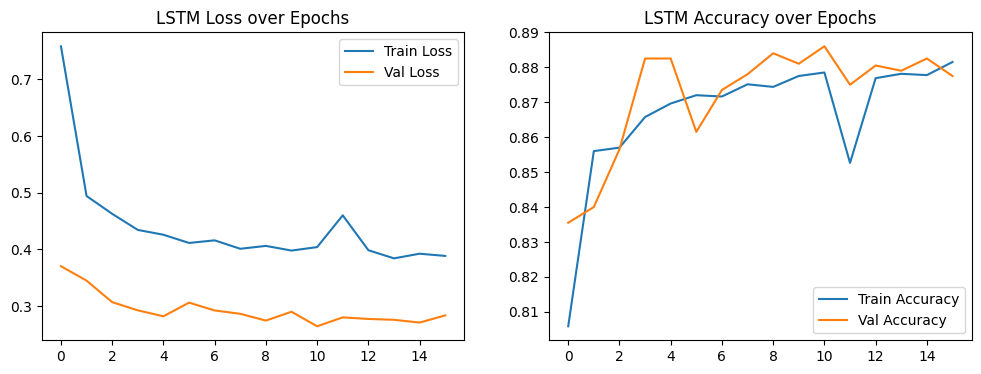


Predicting on Test Data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

   Stable (0)       0.44      0.83      0.58       167
   Escape (1)       0.84      0.70      0.76       398
Collision (2)       1.00      0.94      0.97      1435

     accuracy                           0.89      2000
    macro avg       0.76      0.83      0.77      2000
 weighted avg       0.92      0.89      0.90      2000


--- CONFUSION MATRIX ---


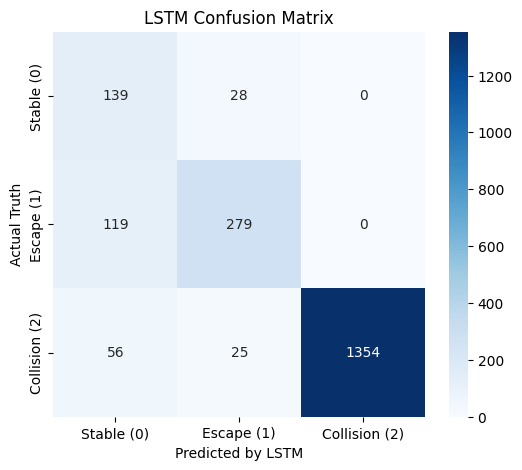

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# STEP 0: FEATURE CONTROL (NEW)
# ==========================================
# This is the master list of all 18 features in your X_enhanced array
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

# CHANGE THIS LIST to control which features the LSTM uses!
# Right now, it's set to use the Top 6 features from your graph.
SELECTED_FEATURES = [
    "Dist_2_3", 
    "Speed_3", 
    "Speed_2", 
    "Vx1", 
    "Vy1", 
    "X2", 
    "Vx2", 
    "Y2", 
    "Vy2", 
    "Vy3"
]

# Find the column indices for the features you selected
selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]
print(f"Selected {len(SELECTED_FEATURES)} features: {SELECTED_FEATURES}")

# ==========================================
# STEP 1: PREPARE THE 3D TIME-SERIES DATA
# ==========================================
print("\nPreparing Data for LSTM...")
OBSERVATION_STEPS = 300  # Only look at the first 50 time steps!

# Slice the time steps AND filter to only use the selected feature columns
X_lstm = X_enhanced[:, :OBSERVATION_STEPS, selected_indices] 
print(f"Data shape after feature selection: {X_lstm.shape}")

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# STEP 2: SCALE THE DATA (Crucial for Neural Networks)
# ==========================================
# LSTM needs 3D data, but StandardScaler only works on 2D data.
# We flatten, scale, and reshape back to 3D.
scaler = StandardScaler()

# Flatten to 2D
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

# Scale
X_train_scaled_flat = scaler.fit_transform(X_train_flat)
X_test_scaled_flat = scaler.transform(X_test_flat) # ONLY transform test data

# Reshape back to 3D
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
X_test_scaled = X_test_scaled_flat.reshape(X_test.shape)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

# ==========================================
# STEP 3: HANDLE CLASS IMBALANCE
# ==========================================
# Calculate weights so the AI doesn't just guess "Collision" every time
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(f"Class Weights applied: {class_weights}")

# ==========================================
# STEP 4: BUILD THE LSTM MODEL
# ==========================================
print("\nBuilding LSTM Model...")
model_lstm = Sequential([
    # LSTM layer reads the sequence. input_shape = (timesteps, features)
    LSTM(64, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), return_sequences=False),
    
    # Dropout randomly turns off neurons to prevent overfitting
    Dropout(0.3),
    
    # Fully connected hidden layer
    Dense(32, activation='relu'),
    
    # Output layer: 3 neurons for Stable, Escape, Collision (Softmax for probabilities)
    Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

# ==========================================
# STEP 5: TRAIN THE MODEL
# ==========================================
print("\nTraining LSTM...")
# EarlyStopping stops training if the model stops improving, saving you time!
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model_lstm.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150,
    batch_size=64,
    class_weight=class_weights, # Apply the weights here!
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# STEP 6: EVALUATE AND PLOT RESULTS
# ==========================================
# 1. Plot Training History (Loss & Accuracy)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('LSTM Loss over Epochs')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('LSTM Accuracy over Epochs')
ax[1].legend()
plt.show()

# 2. Confusion Matrix & Classification Report
print("\nPredicting on Test Data...")
y_pred_probs = model_lstm.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- CLASSIFICATION REPORT ---")
target_names = ['Stable (0)', 'Escape (1)', 'Collision (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted by LSTM')
plt.ylabel('Actual Truth')
plt.title('LSTM Confusion Matrix')
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import time

# ==========================================
# FEATURE CONTROL
# ==========================================
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

# Using the top 6 features that performed best
SELECTED_FEATURES = [
    "Dist_2_3", 
    "Speed_3", 
    "Speed_2", 
    "Vx1", 
    "Vy1", 
    "X2", 
    "Vx2", 
    "Y2", 
    "Vy2", 
    "Vy3"
]

selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# ==========================================
# OBSERVATION TIME SWEEP
# ==========================================
observation_times = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

results = {
    'observation_steps': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("="*60)
print("OBSERVATION TIME SWEEP EXPERIMENT")
print("="*60)
print(f"Testing {len(observation_times)} different observation windows...")
print(f"Features used: {SELECTED_FEATURES}")
print("="*60)

# ==========================================
# LOOP THROUGH EACH OBSERVATION TIME
# ==========================================
for i, obs_steps in enumerate(observation_times):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(observation_times)}] Testing {obs_steps} observation steps...")
    
    # Step 1: Prepare Data
    X_obs = X_enhanced[:, :obs_steps, selected_indices]
    
    # Step 2: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Step 3: Scale Data
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])
    
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)
    
    # Step 4: Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))
    
    # Step 5: Build Model (Using Bidirectional LSTM for better performance)
    tf.keras.backend.clear_session()  # Clear memory between models
    
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), 
                     input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Step 6: Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training to keep output clean
    )
    
    # Step 7: Evaluate
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    
    # Get F1 scores for each class
    from sklearn.metrics import f1_score
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['observation_steps'].append(obs_steps)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")

# ==========================================
# PLOT RESULTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING PLOTS...")
print("="*60)

# Plot 1: Accuracy vs Observation Time
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(results['observation_steps'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(results['observation_steps'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2, markersize=8)
plt.plot(results['observation_steps'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

# Plot 2: F1-Score per Class vs Observation Time
plt.subplot(1, 2, 2)
plt.plot(results['observation_steps'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2, markersize=8)
plt.plot(results['observation_steps'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2, markersize=8)
plt.plot(results['observation_steps'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2, markersize=8)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Score per Class vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("SUMMARY TABLE: ACCURACY BY OBSERVATION TIME")
print("="*80)
print(f"{'Obs Steps':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(observation_times)):
    print(f"{results['observation_steps'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

# ==========================================
# FIND BEST OBSERVATION TIME
# ==========================================
best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST OBSERVATION TIME: {results['observation_steps'][best_idx]} steps")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

OBSERVATION TIME SWEEP EXPERIMENT
Testing 12 different observation windows...
Features used: ['Dist_2_3', 'Speed_3', 'Speed_2', 'Vx1', 'Vy1', 'X2', 'Vx2', 'Y2', 'Vy2', 'Vy3']

[1/12] Testing 25 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.6250 | Time: 19.1s

[2/12] Testing 50 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.7580 | Time: 43.5s

[3/12] Testing 75 observation steps...


...

C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9190 | Time: 202.3s

[9/12] Testing 225 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9055 | Time: 112.4s

[10/12] Testing 250 observation steps...


MemoryError: Unable to allocate 191. MiB for an array with shape (10, 10000, 250) and data type float64

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# FEATURE CONTROL
# ==========================================
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

# Using the top features (Same as LSTM for a fair comparison)
SELECTED_FEATURES = [
    "Dist_2_3", 
    "Speed_3", 
    "Speed_2", 
    "Vx1", 
    "Vy1", 
    "X2", 
    "Vx2", 
    "Y2", 
    "Vy2", 
    "Vy3"
]

selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# ==========================================
# OBSERVATION TIME SWEEP
# ==========================================
observation_times = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

results = {
    'observation_steps': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("="*60)
print("MLP OBSERVATION TIME SWEEP EXPERIMENT")
print("="*60)
print(f"Testing {len(observation_times)} different observation windows...")
print(f"Features used: {SELECTED_FEATURES}")
print("="*60)

# ==========================================
# LOOP THROUGH EACH OBSERVATION TIME
# ==========================================
for i, obs_steps in enumerate(observation_times):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(observation_times)}] Testing {obs_steps} observation steps...")
    
    # Step 1: Prepare Data
    X_obs = X_enhanced[:, :obs_steps, selected_indices]
    
    # Step 2: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Step 3: Scale Data
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])
    
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)
    
    # Step 4: Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))
    
    # Step 5: Build MLP Model
    tf.keras.backend.clear_session()
    
    model = Sequential([
        # FLATTEN LAYER: Smashes the 2D (time x features) matrix into a 1D row
        Flatten(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
        
        # Standard Dense (Fully Connected) layers for MLP
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        
        # Output layer
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Step 6: Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # Step 7: Evaluate
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['observation_steps'].append(obs_steps)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")

# ==========================================
# PLOT RESULTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Observation Time
plt.subplot(1, 2, 1)
plt.plot(results['observation_steps'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('MLP Accuracy vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

# Plot 2: F1-Score per Class vs Observation Time
plt.subplot(1, 2, 2)
plt.plot(results['observation_steps'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['observation_steps'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['observation_steps'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('MLP F1-Score per Class vs Observation Window', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("MLP SUMMARY TABLE: ACCURACY BY OBSERVATION TIME")
print("="*80)
print(f"{'Obs Steps':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(observation_times)):
    print(f"{results['observation_steps'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

# ==========================================
# FIND BEST OBSERVATION TIME
# ==========================================
best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST MLP OBSERVATION TIME: {results['observation_steps'][best_idx]} steps")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

MLP OBSERVATION TIME SWEEP EXPERIMENT
Testing 12 different observation windows...
Features used: ['Dist_2_3', 'Speed_3', 'Speed_2', 'Vx1', 'Vy1', 'X2', 'Vx2', 'Y2', 'Vy2', 'Vy3']

[1/12] Testing 25 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.6480 | Time: 4.6s

[2/12] Testing 50 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.7700 | Time: 7.2s

[3/12] Testing 75 observation steps...


...

C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9100 | Time: 5.6s

[10/12] Testing 250 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9140 | Time: 7.7s

[11/12] Testing 275 observation steps...


MemoryError: Unable to allocate 210. MiB for an array with shape (10, 10000, 275) and data type float64

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Concatenate, BatchNormalization, Lambda

print("="*60)
print("BUILDING PHYSICS-INFORMED NEURAL NETWORK (PINN)")
print("="*60)

# ==========================================
# STEP 1: PREPARE RAW DATA (Must be unscaled for physics!)
# ==========================================
OBSERVATION_STEPS = 150  # We use 100 steps (a solid sweet spot from your sweeps)

# We MUST use the raw X_tensor (the original 12 features: x, y, vx, vy)
# so the physical equations inside the network calculate correctly.
X_pinn = X_tensor[:, :OBSERVATION_STEPS, :] # Shape: (10000, 100, 12)

X_train, X_test, y_train, y_test = train_test_split(
    X_pinn, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Class weights
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# ==========================================
# STEP 2: DEFINE THE PHYSICS LAWS (Inside TensorFlow)
# ==========================================
# This function lives INSIDE the neural network. It calculates actual physics.
def physics_equations(inputs):
    # inputs shape: (batch_size, time_steps, 12)
    x1, y1, vx1, vy1 = inputs[:,:,0], inputs[:,:,1], inputs[:,:,2], inputs[:,:,3]
    x2, y2, vx2, vy2 = inputs[:,:,4], inputs[:,:,5], inputs[:,:,6], inputs[:,:,7]
    x3, y3, vx3, vy3 = inputs[:,:,8], inputs[:,:,9], inputs[:,:,10], inputs[:,:,11]
    
    # 1. Distances (add a tiny epsilon 1e-6 to prevent dividing by zero)
    r12 = tf.sqrt(tf.square(x1 - x2) + tf.square(y1 - y2) + 1e-6)
    r23 = tf.sqrt(tf.square(x2 - x3) + tf.square(y2 - y3) + 1e-6)
    r13 = tf.sqrt(tf.square(x1 - x3) + tf.square(y1 - y3) + 1e-6)
    
    # 2. Potential Energy (U = -G * m1*m2 / r)
    # Assuming G=1 and masses are roughly 1 for the network's understanding
    U = -1.0 * (1.0/r12 + 1.0/r23 + 1.0/r13)
    
    # 3. Kinetic Energy (K = 0.5 * m * v^2)
    K1 = 0.5 * (tf.square(vx1) + tf.square(vy1))
    K2 = 0.5 * (tf.square(vx2) + tf.square(vy2))
    K3 = 0.5 * (tf.square(vx3) + tf.square(vy3))
    K_total = K1 + K2 + K3
    
    # 4. Total Energy (E = K + U)
    # Physics rule: If E > 0, system is unbound (predicts Escape!)
    E_total = K_total + U
    
    # 5. Angular Momentum (L = r x v)
    L1 = x1*vy1 - y1*vx1
    L2 = x2*vy2 - y2*vx2
    L3 = x3*vy3 - y3*vx3
    L_total = L1 + L2 + L3
    
    # Take the average of these physical laws over the observation time
    E_mean = tf.reduce_mean(E_total, axis=1, keepdims=True)
    K_mean = tf.reduce_mean(K_total, axis=1, keepdims=True)
    U_mean = tf.reduce_mean(U, axis=1, keepdims=True)
    L_mean = tf.reduce_mean(L_total, axis=1, keepdims=True)
    
    # Return the physics features
    return tf.concat([E_mean, K_mean, U_mean, L_mean], axis=-1)

# ==========================================
# STEP 3: BUILD THE DUAL-BRANCH PINN ARCHITECTURE
# ==========================================
tf.keras.backend.clear_session()

# The Input Layer
inputs = Input(shape=(OBSERVATION_STEPS, 12), name="Raw_Physics_Input")

# --- BRANCH 1: The Physics Brain ---
# Passes raw, unscaled data through Newton's equations
physics_features = Lambda(physics_equations, name="Physics_Equations_Layer")(inputs)
physics_dense = Dense(16, activation='relu', name="Physics_Processing")(physics_features)

# --- BRANCH 2: The Data Brain ---
# Neural networks need scaled data to train properly. 
# We use BatchNormalization to scale the data INSIDE the network for the LSTM!
scaled_inputs = BatchNormalization(name="Internal_Scaler")(inputs)
lstm_out = LSTM(64, return_sequences=False, name="LSTM_Pattern_Reader")(scaled_inputs)
lstm_dense = Dense(32, activation='relu')(lstm_out)
lstm_dense = Dropout(0.3)(lstm_dense)

# --- MERGE: Combine Physics and Data ---
merged = Concatenate(name="Merge_Physics_And_Data")([physics_dense, lstm_dense])

# --- OUTPUT LAYER ---
outputs = Dense(3, activation='softmax', name="Final_Prediction")(merged)

# Compile Model
model_pinn = Model(inputs=inputs, outputs=outputs, name="PINN_3Body")
model_pinn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_pinn.summary()

# ==========================================
# STEP 4: TRAIN THE PINN
# ==========================================
print("\nTraining PINN...")
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_pinn.fit(
    X_train, y_train, # Notice we pass RAW data, the network scales it internally!
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# STEP 5: EVALUATE & PLOT
# ==========================================
print("\n" + "="*60)
print("PINN EXPERIMENT COMPLETE!")
print("="*60)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('PINN Loss over Epochs')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('PINN Accuracy over Epochs')
ax[1].legend()
plt.show()

# Predictions
y_pred_probs = model_pinn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- CLASSIFICATION REPORT ---")
target_names = ['Stable (0)', 'Escape (1)', 'Collision (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted by PINN')
plt.ylabel('Actual Truth')
plt.title('Physics-Informed Neural Network (PINN) Confusion Matrix')
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Concatenate, BatchNormalization, Lambda
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# PHYSICS EQUATIONS (Runs inside the network)
# ==========================================
def physics_equations(inputs):
    # inputs shape: (batch_size, time_steps, 12)
    x1, y1, vx1, vy1 = inputs[:,:,0], inputs[:,:,1], inputs[:,:,2], inputs[:,:,3]
    x2, y2, vx2, vy2 = inputs[:,:,4], inputs[:,:,5], inputs[:,:,6], inputs[:,:,7]
    x3, y3, vx3, vy3 = inputs[:,:,8], inputs[:,:,9], inputs[:,:,10], inputs[:,:,11]
    
    # 1. Distances
    r12 = tf.sqrt(tf.square(x1 - x2) + tf.square(y1 - y2) + 1e-6)
    r23 = tf.sqrt(tf.square(x2 - x3) + tf.square(y2 - y3) + 1e-6)
    r13 = tf.sqrt(tf.square(x1 - x3) + tf.square(y1 - y3) + 1e-6)
    
    # 2. Potential Energy (U)
    U = -1.0 * (1.0/r12 + 1.0/r23 + 1.0/r13)
    
    # 3. Kinetic Energy (K)
    K1 = 0.5 * (tf.square(vx1) + tf.square(vy1))
    K2 = 0.5 * (tf.square(vx2) + tf.square(vy2))
    K3 = 0.5 * (tf.square(vx3) + tf.square(vy3))
    K_total = K1 + K2 + K3
    
    # 4. Total Energy (E)
    E_total = K_total + U
    
    # 5. Angular Momentum (L)
    L1 = x1*vy1 - y1*vx1
    L2 = x2*vy2 - y2*vx2
    L3 = x3*vy3 - y3*vx3
    L_total = L1 + L2 + L3
    
    # Time average
    E_mean = tf.reduce_mean(E_total, axis=1, keepdims=True)
    K_mean = tf.reduce_mean(K_total, axis=1, keepdims=True)
    U_mean = tf.reduce_mean(U, axis=1, keepdims=True)
    L_mean = tf.reduce_mean(L_total, axis=1, keepdims=True)
    
    return tf.concat([E_mean, K_mean, U_mean, L_mean], axis=-1)

# ==========================================
# OBSERVATION TIME SWEEP SETUP
# ==========================================
observation_times = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

results = {
    'observation_steps': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("="*60)
print("PINN OBSERVATION TIME SWEEP EXPERIMENT")
print("="*60)
print(f"Testing {len(observation_times)} different observation windows...")
print("Using ONLY the 12 RAW unscaled features for true physics calculations.")
print("="*60)

# ==========================================
# LOOP THROUGH EACH OBSERVATION TIME
# ==========================================
for i, obs_steps in enumerate(observation_times):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(observation_times)}] Testing {obs_steps} observation steps...")
    
    # Step 1: Prepare RAW Data (Using X_tensor, NOT X_enhanced)
    X_obs = X_tensor[:, :obs_steps, :]
    
    # Step 2: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Notice: NO STANDARD SCALER HERE! The PINN scales internally.
    
    # Step 3: Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))
    
    # Step 4: Build PINN Model
    tf.keras.backend.clear_session()
    
    inputs = Input(shape=(obs_steps, 12), name="Raw_Physics_Input")
    
    # Branch 1: Physics
    physics_features = Lambda(physics_equations, name="Physics_Math")(inputs)
    physics_dense = Dense(16, activation='relu')(physics_features)
    
    # Branch 2: Data (LSTM with internal scaling)
    scaled_inputs = BatchNormalization(name="Internal_Scaler")(inputs)
    lstm_out = LSTM(64, return_sequences=False)(scaled_inputs)
    lstm_dense = Dense(32, activation='relu')(lstm_out)
    lstm_dense = Dropout(0.3)(lstm_dense)
    
    # Merge and Output
    merged = Concatenate()([physics_dense, lstm_dense])
    outputs = Dense(3, activation='softmax')(merged)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Step 5: Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train, # Feeding RAW data
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # Step 6: Evaluate
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['observation_steps'].append(obs_steps)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")

# ==========================================
# PLOT RESULTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Observation Time
plt.subplot(1, 2, 1)
plt.plot(results['observation_steps'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('PINN Accuracy vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

# Plot 2: F1-Score per Class vs Observation Time
plt.subplot(1, 2, 2)
plt.plot(results['observation_steps'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['observation_steps'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['observation_steps'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('PINN F1-Score per Class vs Observation Window', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("PINN SUMMARY TABLE: ACCURACY BY OBSERVATION TIME")
print("="*80)
print(f"{'Obs Steps':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(observation_times)):
    print(f"{results['observation_steps'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST PINN OBSERVATION TIME: {results['observation_steps'][best_idx]} steps")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

PINN OBSERVATION TIME SWEEP EXPERIMENT
Testing 1 different observation windows...
Using ONLY the 12 RAW unscaled features for true physics calculations.

[1/1] Testing 300 observation steps...



KeyboardInterrupt: 

PINN OBSERVATION TIME SWEEP EXPERIMENT
Testing 12 different observation windows...
Using ONLY the 12 RAW unscaled features for true physics calculations.

[1/12] Testing 25 observation steps...
   Test Accuracy: 0.6690 | Time: 24.5s


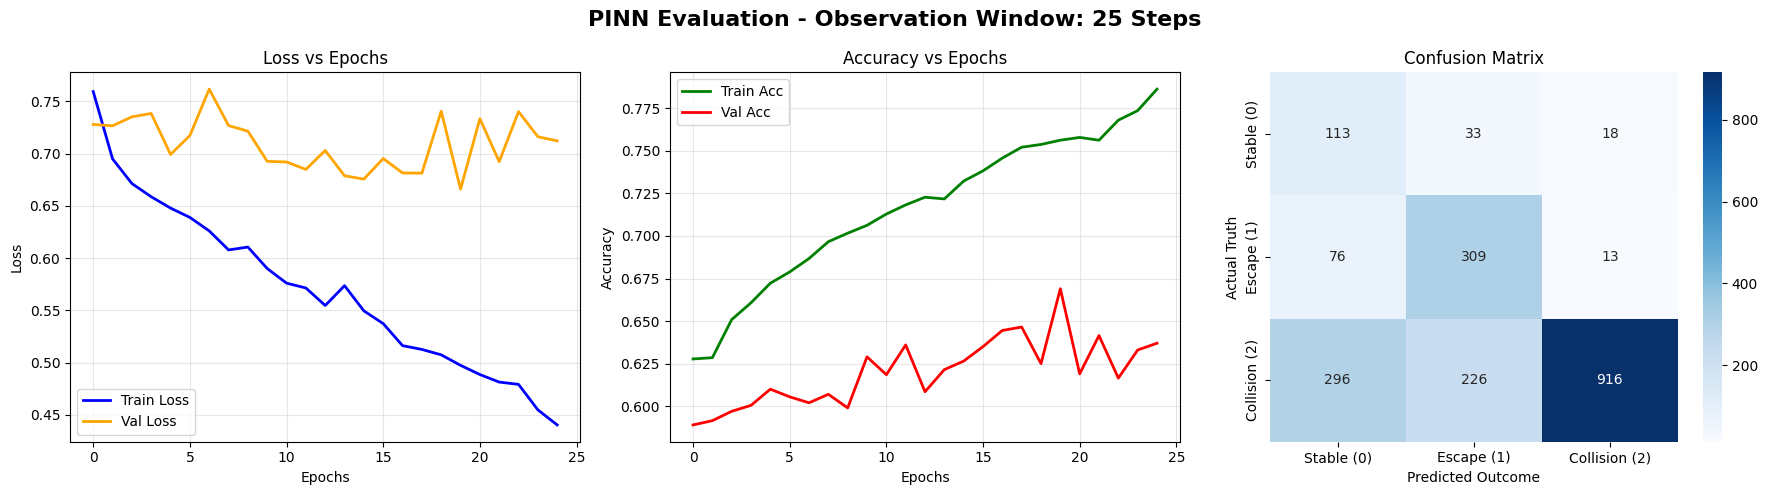


[2/12] Testing 50 observation steps...
   Test Accuracy: 0.7165 | Time: 13.6s


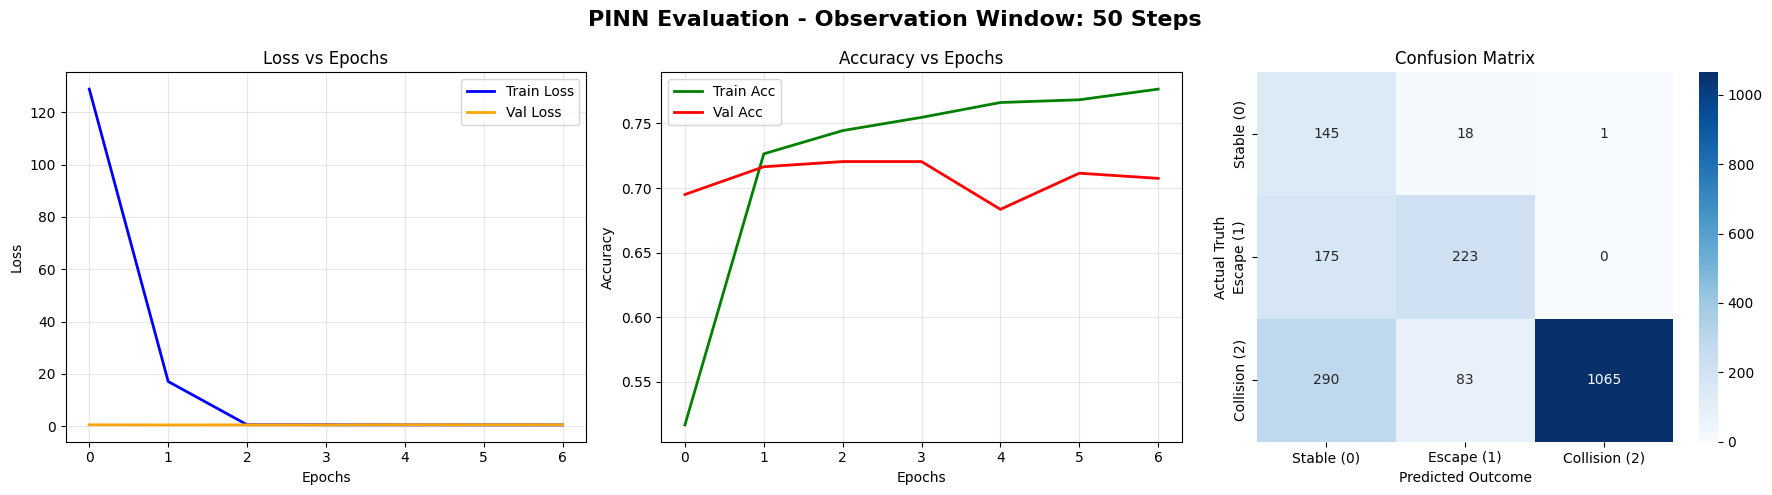


[3/12] Testing 75 observation steps...
   Test Accuracy: 0.8265 | Time: 20.4s


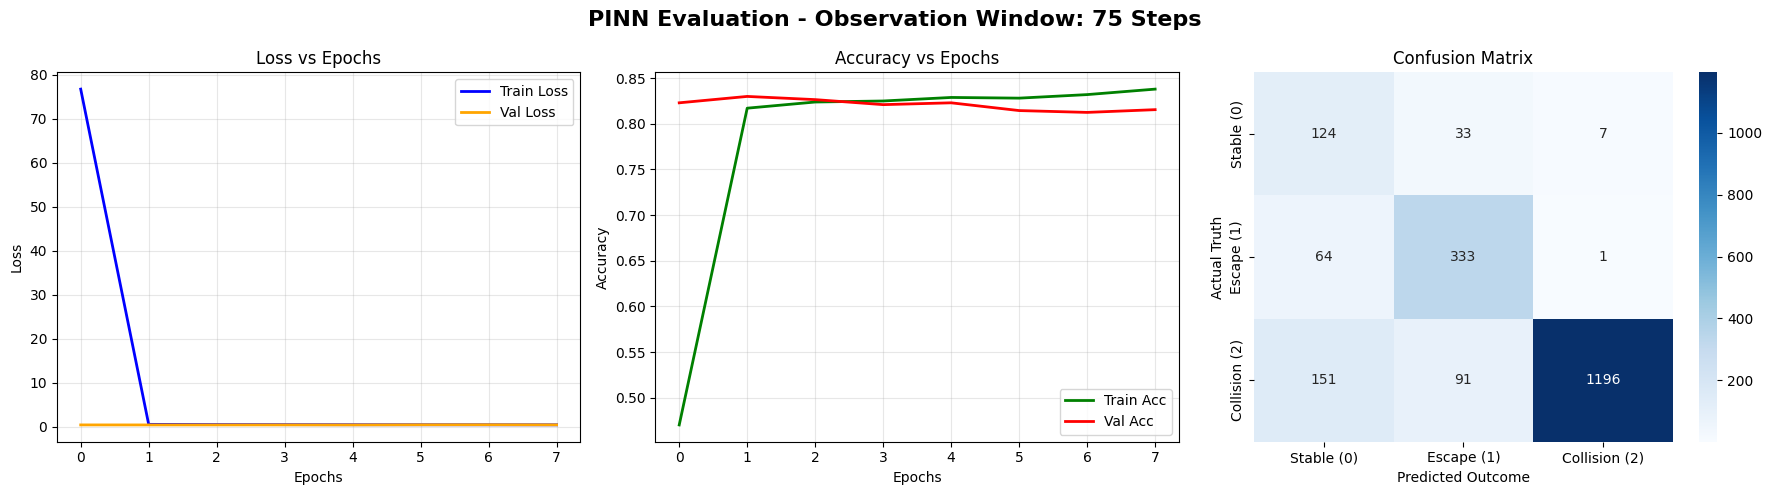


[4/12] Testing 100 observation steps...
   Test Accuracy: 0.7185 | Time: 23.2s


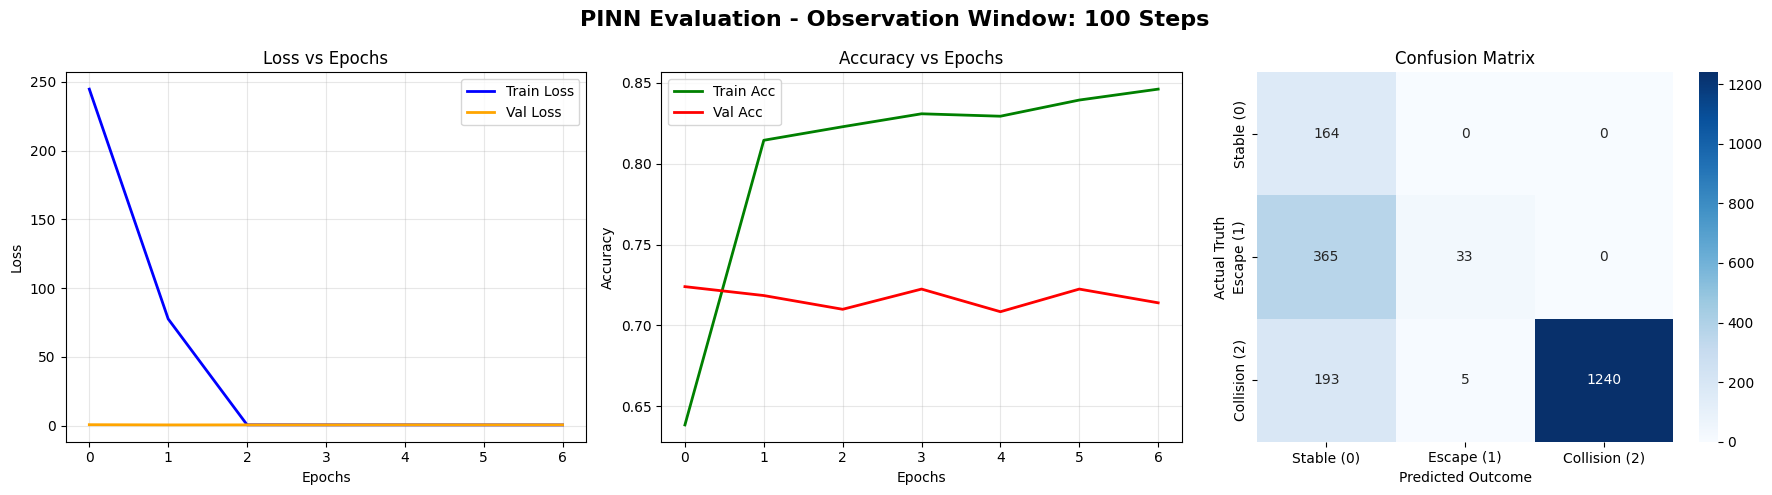


[5/12] Testing 125 observation steps...
   Test Accuracy: 0.8655 | Time: 89.6s


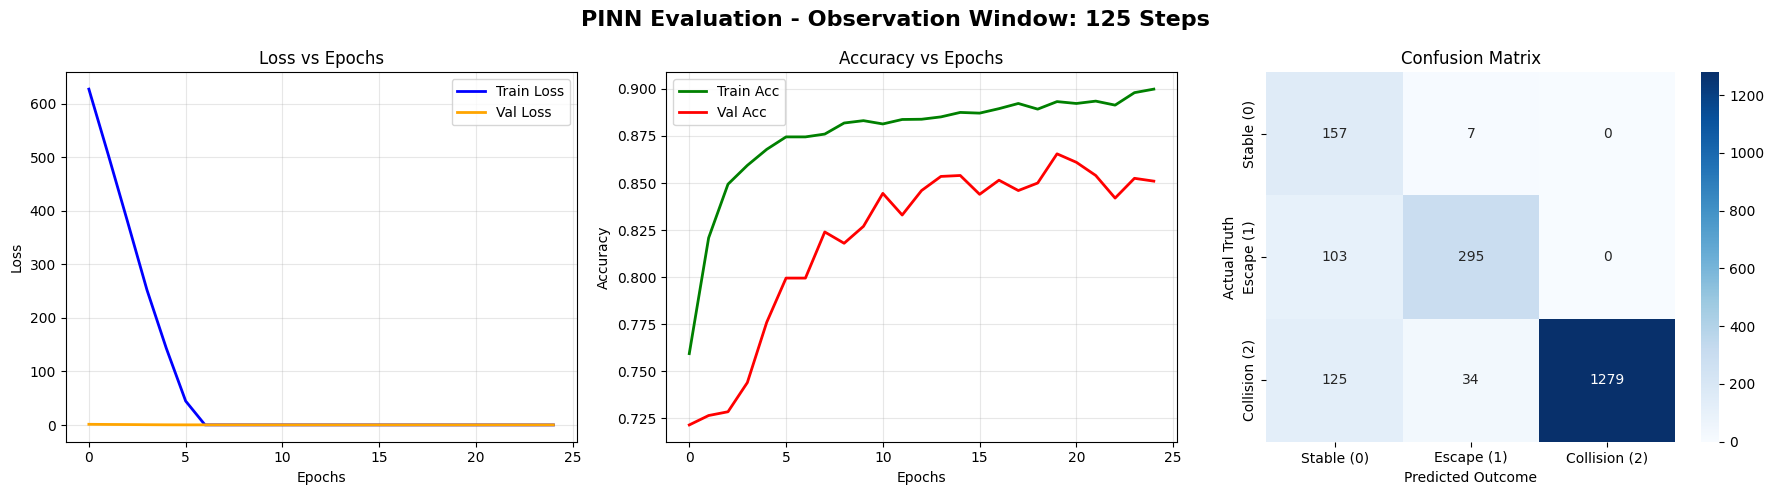


[6/12] Testing 150 observation steps...
   Test Accuracy: 0.8935 | Time: 99.5s


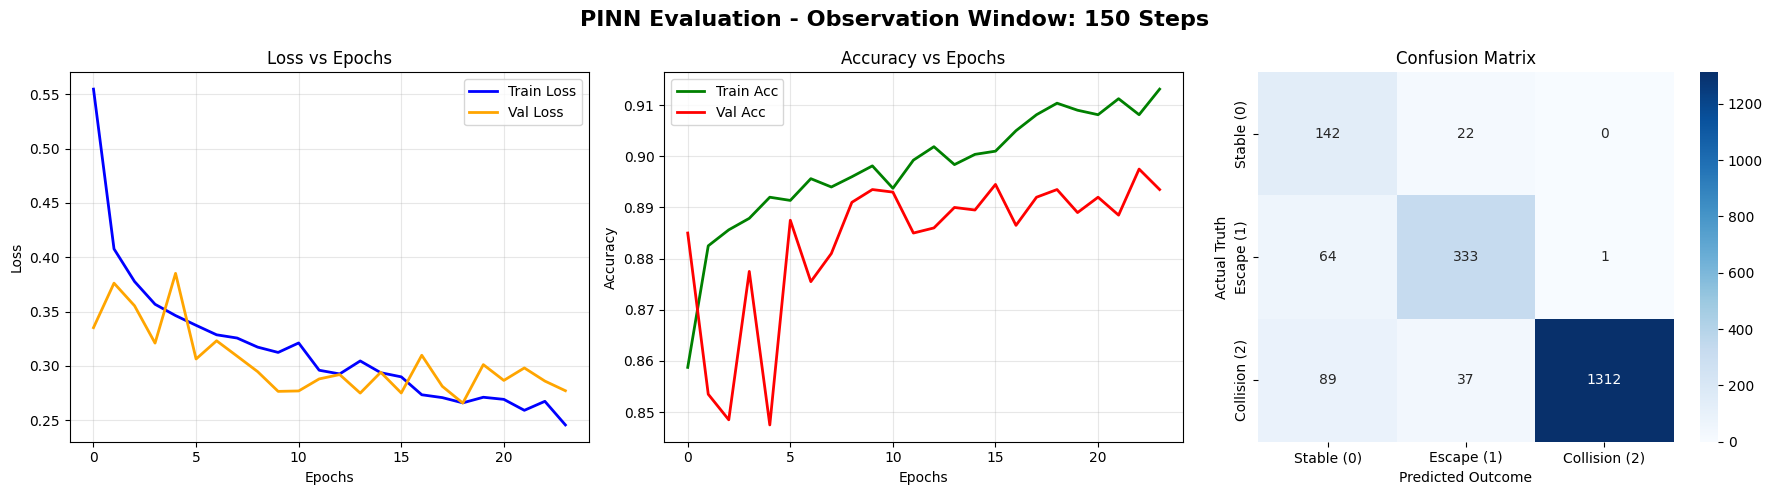


[7/12] Testing 175 observation steps...
   Test Accuracy: 0.9020 | Time: 50.7s


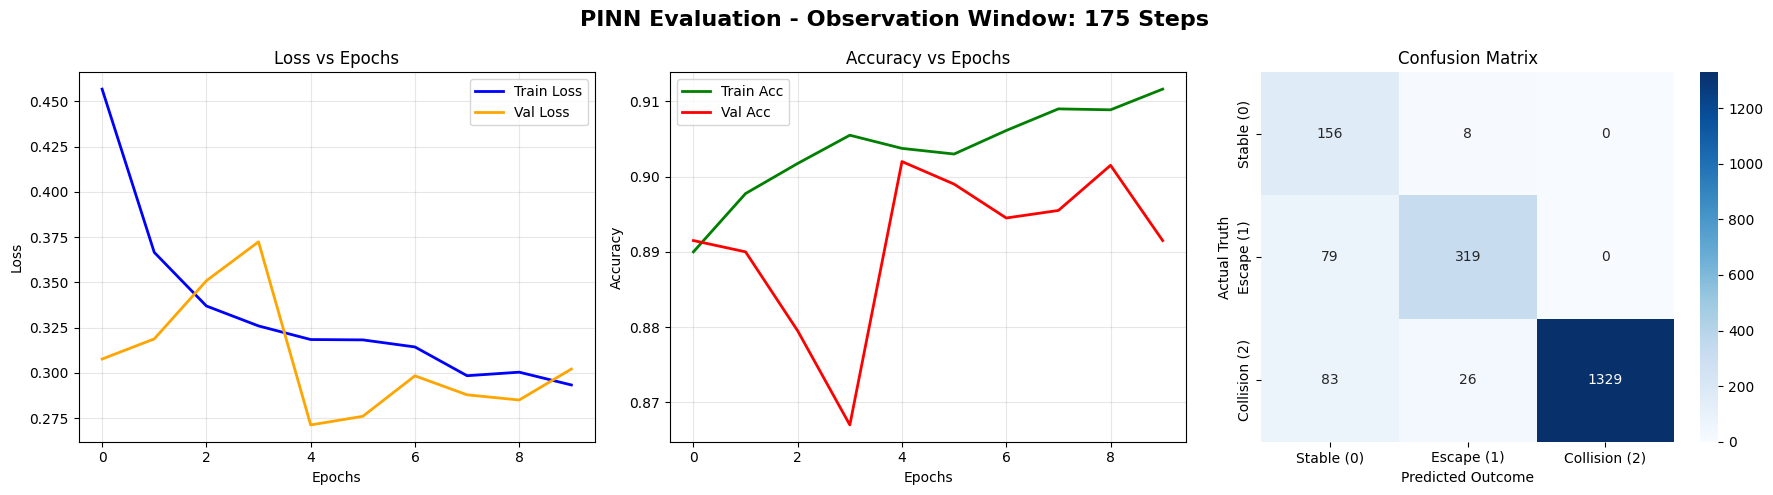


[8/12] Testing 200 observation steps...
   Test Accuracy: 0.8445 | Time: 35.4s


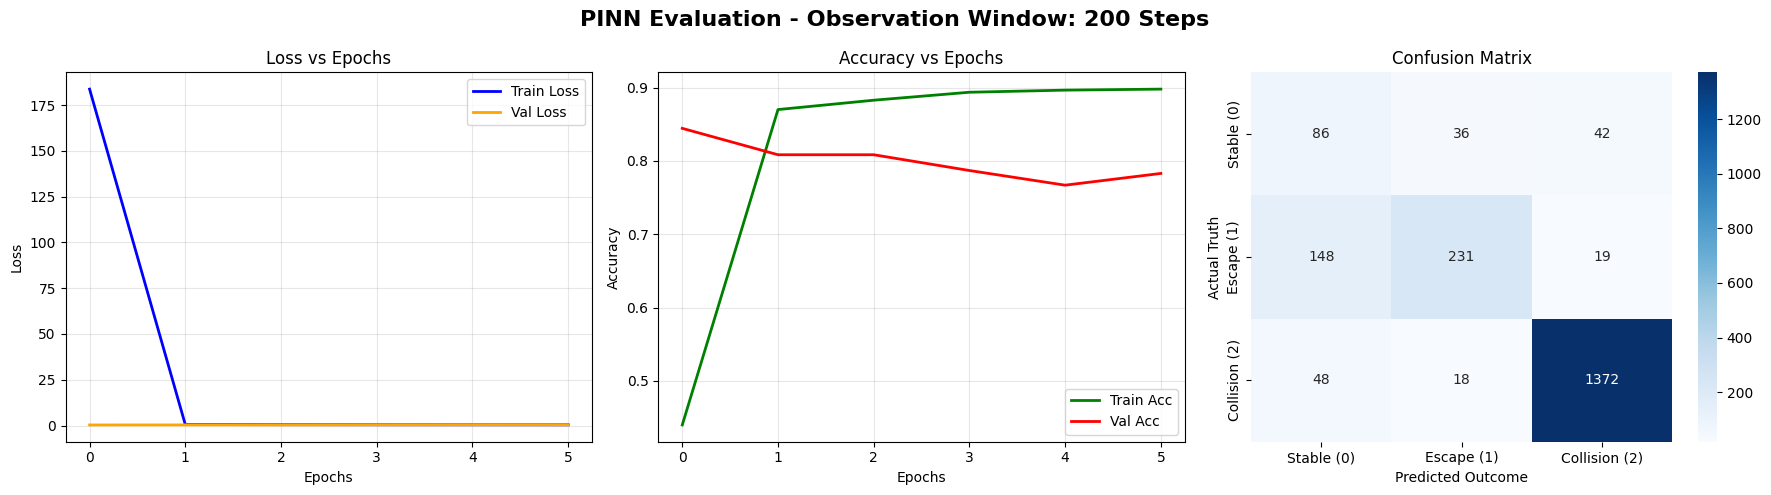


[9/12] Testing 225 observation steps...
   Test Accuracy: 0.9175 | Time: 127.0s


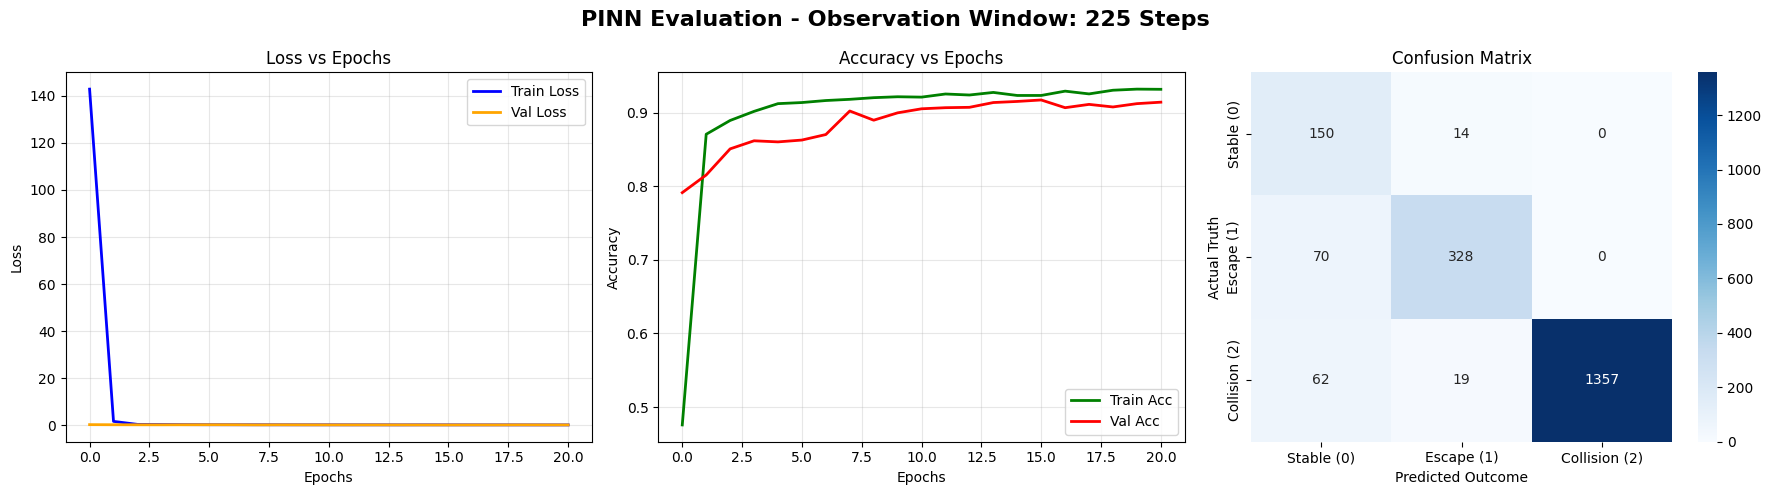


[10/12] Testing 250 observation steps...
   Test Accuracy: 0.9280 | Time: 126.1s


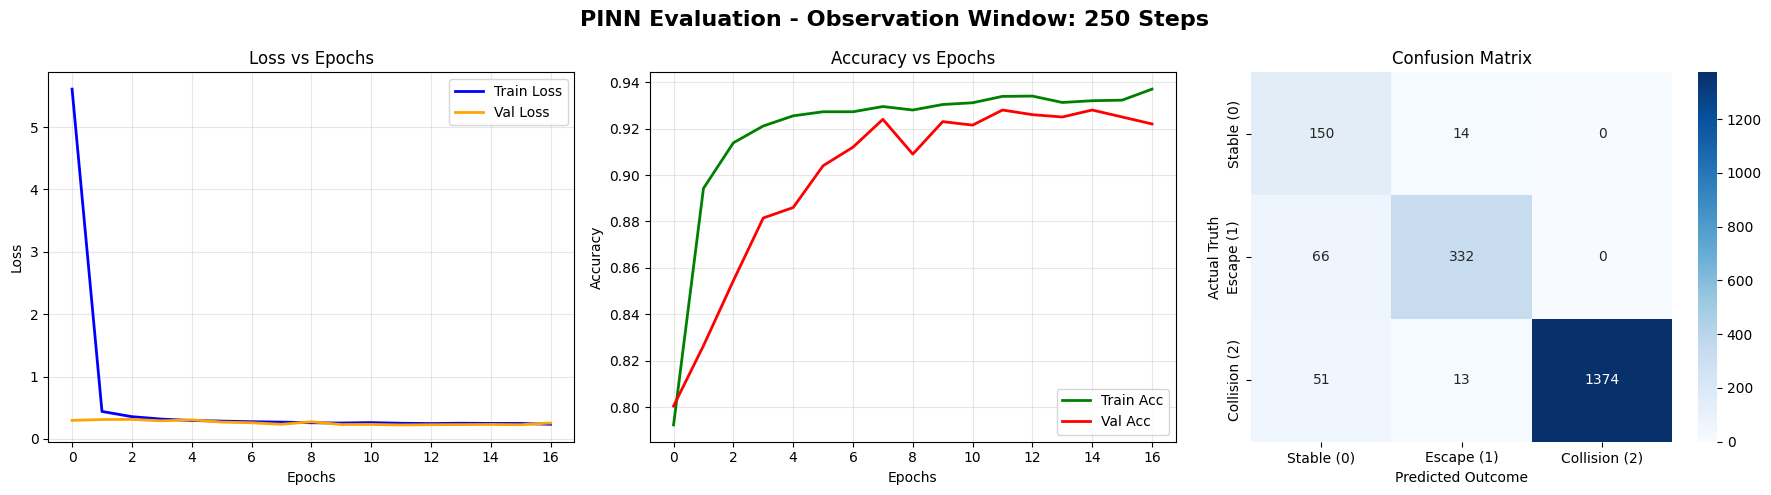


[11/12] Testing 275 observation steps...
   Test Accuracy: 0.9250 | Time: 144.3s


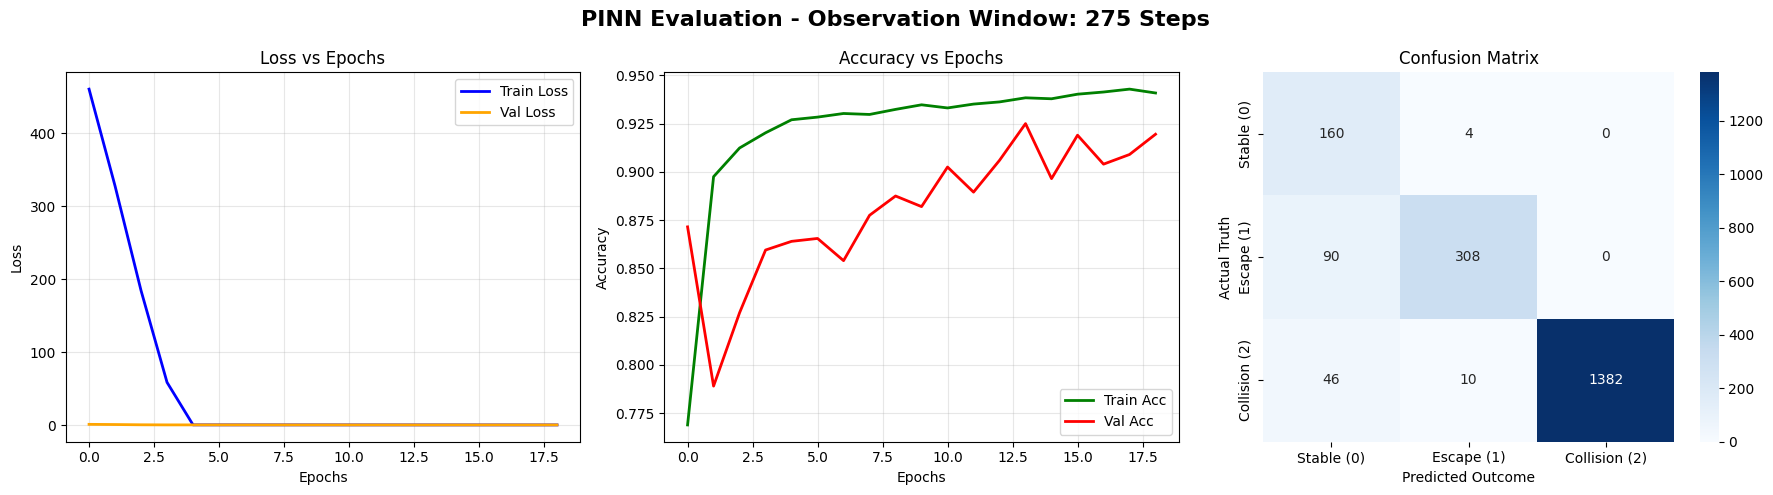


[12/12] Testing 300 observation steps...
   Test Accuracy: 0.9345 | Time: 108.1s


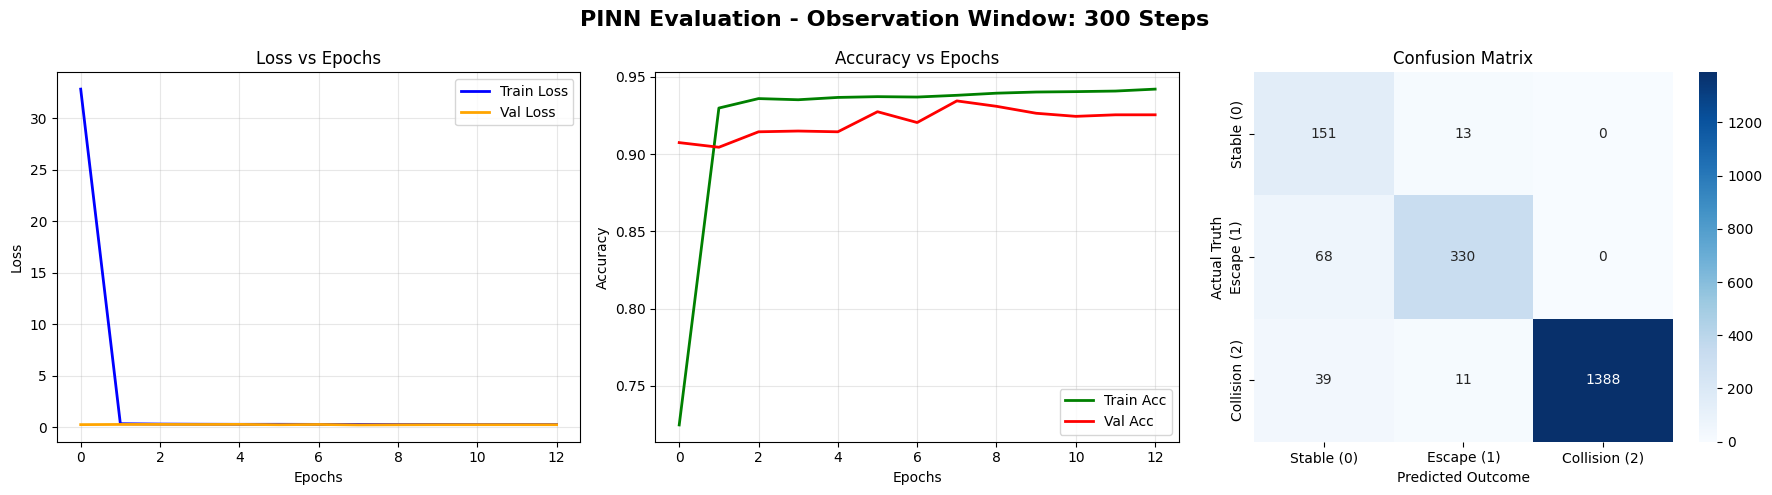


EXPERIMENT COMPLETE! GENERATING FINAL SUMMARY PLOTS...


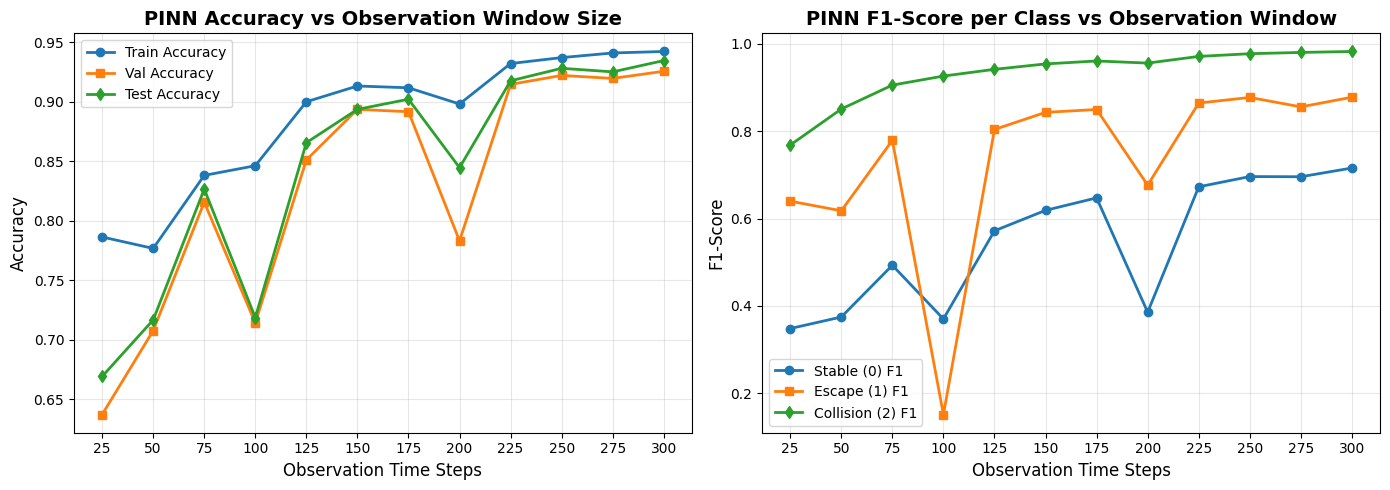


PINN SUMMARY TABLE: ACCURACY BY OBSERVATION TIME
Obs Steps    Train Acc    Val Acc      Test Acc     Stable F1    Escape F1    Collision F1
--------------------------------------------------------------------------------
25           0.7862       0.6370       0.6690       0.3482       0.6398       0.7681      
50           0.7766       0.7075       0.7165       0.3747       0.6177       0.8506      
75           0.8380       0.8155       0.8265       0.4930       0.7789       0.9054      
100          0.8461       0.7140       0.7185       0.3702       0.1514       0.9261      
125          0.8999       0.8510       0.8655       0.5719       0.8038       0.9415      
150          0.9131       0.8935       0.8935       0.6187       0.8430       0.9538      
175          0.9116       0.8915       0.9020       0.6473       0.8495       0.9606      
200          0.8980       0.7830       0.8445       0.3857       0.6764       0.9558      
225          0.9320       0.9145       0.9175     

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Concatenate, BatchNormalization, Lambda
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# PHYSICS EQUATIONS (Runs inside the network)
# ==========================================
def physics_equations(inputs):
    # inputs shape: (batch_size, time_steps, 12)
    x1, y1, vx1, vy1 = inputs[:,:,0], inputs[:,:,1], inputs[:,:,2], inputs[:,:,3]
    x2, y2, vx2, vy2 = inputs[:,:,4], inputs[:,:,5], inputs[:,:,6], inputs[:,:,7]
    x3, y3, vx3, vy3 = inputs[:,:,8], inputs[:,:,9], inputs[:,:,10], inputs[:,:,11]
    
    # 1. Distances
    r12 = tf.sqrt(tf.square(x1 - x2) + tf.square(y1 - y2) + 1e-6)
    r23 = tf.sqrt(tf.square(x2 - x3) + tf.square(y2 - y3) + 1e-6)
    r13 = tf.sqrt(tf.square(x1 - x3) + tf.square(y1 - y3) + 1e-6)
    
    # 2. Potential Energy (U)
    U = -1.0 * (1.0/r12 + 1.0/r23 + 1.0/r13)
    
    # 3. Kinetic Energy (K)
    K1 = 0.5 * (tf.square(vx1) + tf.square(vy1))
    K2 = 0.5 * (tf.square(vx2) + tf.square(vy2))
    K3 = 0.5 * (tf.square(vx3) + tf.square(vy3))
    K_total = K1 + K2 + K3
    
    # 4. Total Energy (E)
    E_total = K_total + U
    
    # 5. Angular Momentum (L)
    L1 = x1*vy1 - y1*vx1
    L2 = x2*vy2 - y2*vx2
    L3 = x3*vy3 - y3*vx3
    L_total = L1 + L2 + L3
    
    # Time average
    E_mean = tf.reduce_mean(E_total, axis=1, keepdims=True)
    K_mean = tf.reduce_mean(K_total, axis=1, keepdims=True)
    U_mean = tf.reduce_mean(U, axis=1, keepdims=True)
    L_mean = tf.reduce_mean(L_total, axis=1, keepdims=True)
    
    return tf.concat([E_mean, K_mean, U_mean, L_mean], axis=-1)

# ==========================================
# OBSERVATION TIME SWEEP SETUP
# ==========================================
observation_times = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

results = {
    'observation_steps': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("="*60)
print("PINN OBSERVATION TIME SWEEP EXPERIMENT")
print("="*60)
print(f"Testing {len(observation_times)} different observation windows...")
print("Using ONLY the 12 RAW unscaled features for true physics calculations.")
print("="*60)

# ==========================================
# LOOP THROUGH EACH OBSERVATION TIME
# ==========================================
for i, obs_steps in enumerate(observation_times):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(observation_times)}] Testing {obs_steps} observation steps...")
    
    # Step 1: Prepare RAW Data (Using X_tensor, NOT X_enhanced)
    X_obs = X_tensor[:, :obs_steps, :]
    
    # Step 2: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Step 3: Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))
    
    # Step 4: Build PINN Model
    tf.keras.backend.clear_session()
    
    inputs = Input(shape=(obs_steps, 12), name="Raw_Physics_Input")
    
    # Branch 1: Physics
    physics_features = Lambda(physics_equations, name="Physics_Math")(inputs)
    physics_dense = Dense(16, activation='relu')(physics_features)
    
    # Branch 2: Data (LSTM with internal scaling)
    scaled_inputs = BatchNormalization(name="Internal_Scaler")(inputs)
    lstm_out = LSTM(64, return_sequences=False)(scaled_inputs)
    lstm_dense = Dense(32, activation='relu')(lstm_out)
    lstm_dense = Dropout(0.3)(lstm_dense)
    
    # Merge and Output
    merged = Concatenate()([physics_dense, lstm_dense])
    outputs = Dense(3, activation='softmax')(merged)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Step 5: Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train, 
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # Step 6: Evaluate
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['observation_steps'].append(obs_steps)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")
    
    # ==========================================
    # INDIVIDUAL PLOTS FOR THIS OBSERVATION TIME
    # ==========================================
    target_names = ['Stable (0)', 'Escape (1)', 'Collision (2)']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'PINN Evaluation - Observation Window: {obs_steps} Steps', fontsize=16, fontweight='bold')
    
    # Plot A: Loss vs Epochs
    axes[0].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
    axes[0].set_title('Loss vs Epochs')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot B: Accuracy vs Epochs
    axes[1].plot(history.history['accuracy'], label='Train Acc', color='green', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='red', linewidth=2)
    axes[1].set_title('Accuracy vs Epochs')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot C: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], 
                xticklabels=target_names, yticklabels=target_names)
    axes[2].set_title('Confusion Matrix')
    axes[2].set_xlabel('Predicted Outcome')
    axes[2].set_ylabel('Actual Truth')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# FINAL SWEEP SUMMARY PLOTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING FINAL SUMMARY PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Observation Time
plt.subplot(1, 2, 1)
plt.plot(results['observation_steps'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('PINN Accuracy vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

# Plot 2: F1-Score per Class vs Observation Time
plt.subplot(1, 2, 2)
plt.plot(results['observation_steps'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['observation_steps'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['observation_steps'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('PINN F1-Score per Class vs Observation Window', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("PINN SUMMARY TABLE: ACCURACY BY OBSERVATION TIME")
print("="*80)
print(f"{'Obs Steps':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(observation_times)):
    print(f"{results['observation_steps'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST PINN OBSERVATION TIME: {results['observation_steps'][best_idx]} steps")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

Preparing RAW Data ONCE for 200 observation steps...

PINN HYPERPARAMETER SWEEP: LSTM DATA BRANCH CAPACITY
Testing 5 different capacities for the Data Brain...

[1/5] Testing PINN with LSTM size 16...

   Test Accuracy: 0.9090 | Time: 30.0s | Stopped at Epoch 8

[2/5] Testing PINN with LSTM size 32...
   Test Accuracy: 0.8935 | Time: 33.6s | Stopped at Epoch 7

[3/5] Testing PINN with LSTM size 64...
   Test Accuracy: 0.9020 | Time: 230.7s | Stopped at Epoch 28

[4/5] Testing PINN with LSTM size 128...
   Test Accuracy: 0.9010 | Time: 341.0s | Stopped at Epoch 16

[5/5] Testing PINN with LSTM size 256...
   Test Accuracy: 0.9030 | Time: 880.7s | Stopped at Epoch 17

EXPERIMENT COMPLETE! GENERATING HYPERPARAMETER PLOTS...


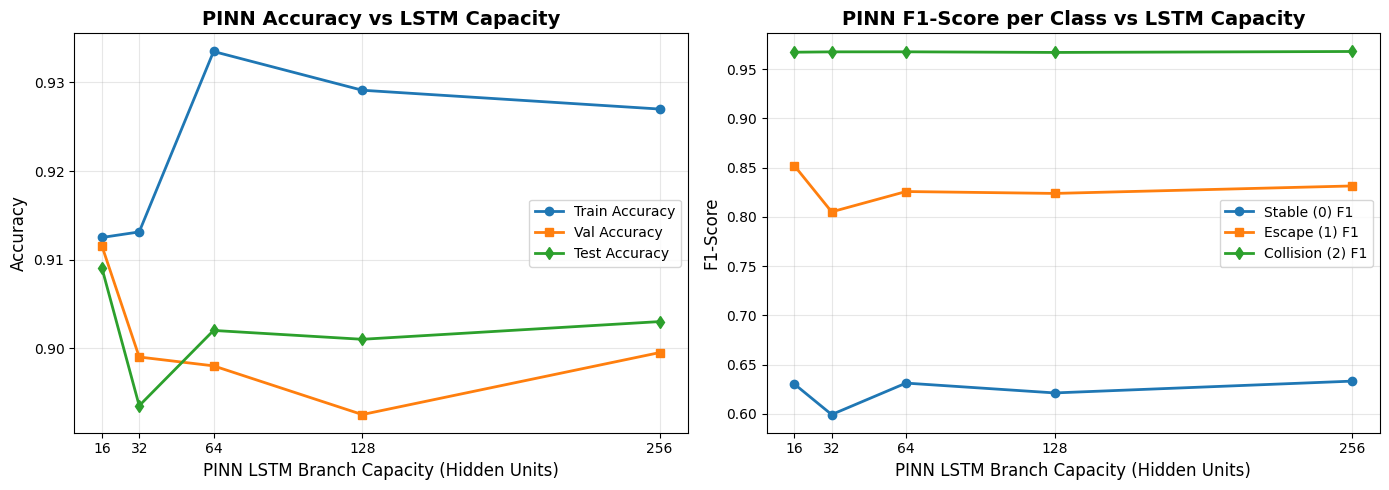


PINN HYPERPARAMETER SUMMARY: ACCURACY BY HIDDEN SIZE
Hidden Size  Train Acc    Val Acc      Test Acc     Stable F1    Escape F1    Collision F1
--------------------------------------------------------------------------------
16           0.9125       0.9115       0.9090       0.6301       0.8517       0.9670      
32           0.9131       0.8990       0.8935       0.5992       0.8050       0.9674      
64           0.9335       0.8980       0.9020       0.6311       0.8256       0.9675      
128          0.9291       0.8925       0.9010       0.6211       0.8237       0.9668      
256          0.9270       0.8995       0.9030       0.6331       0.8313       0.9678      

 BEST PINN CAPACITY: 16 LSTM Hidden Units
   Best Test Accuracy: 0.9090 (90.90%)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
import gc
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Concatenate, BatchNormalization, Lambda
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# MEMORY FIX 1: Convert raw data to float32 
# ==========================================
# PINN uses RAW data (12 features) to calculate physics, not X_enhanced
X_tensor_32 = X_tensor.astype(np.float32)
OBSERVATION_STEPS = 150  # We use 100 steps (a solid sweet spot from your sweeps)

# We MUST use the raw X_tensor (the original 12 features: x, y, vx, vy)
# so the physical equations inside the network calculate correctly.
X_pinn = X_tensor[:, :OBSERVATION_STEPS, :] # Shape: (10000, 100, 12)

X_train, X_test, y_train, y_test = train_test_split(
    X_pinn, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# PHYSICS EQUATIONS (Runs inside the network)
# ==========================================
def physics_equations(inputs):
    x1, y1, vx1, vy1 = inputs[:,:,0], inputs[:,:,1], inputs[:,:,2], inputs[:,:,3]
    x2, y2, vx2, vy2 = inputs[:,:,4], inputs[:,:,5], inputs[:,:,6], inputs[:,:,7]
    x3, y3, vx3, vy3 = inputs[:,:,8], inputs[:,:,9], inputs[:,:,10], inputs[:,:,11]
    
    r12 = tf.sqrt(tf.square(x1 - x2) + tf.square(y1 - y2) + 1e-6)
    r23 = tf.sqrt(tf.square(x2 - x3) + tf.square(y2 - y3) + 1e-6)
    r13 = tf.sqrt(tf.square(x1 - x3) + tf.square(y1 - y3) + 1e-6)
    
    U = -1.0 * (1.0/r12 + 1.0/r23 + 1.0/r13)
    
    K1 = 0.5 * (tf.square(vx1) + tf.square(vy1))
    K2 = 0.5 * (tf.square(vx2) + tf.square(vy2))
    K3 = 0.5 * (tf.square(vx3) + tf.square(vy3))
    K_total = K1 + K2 + K3
    
    E_total = K_total + U
    
    L1 = x1*vy1 - y1*vx1
    L2 = x2*vy2 - y2*vx2
    L3 = x3*vy3 - y3*vx3
    L_total = L1 + L2 + L3
    
    E_mean = tf.reduce_mean(E_total, axis=1, keepdims=True)
    K_mean = tf.reduce_mean(K_total, axis=1, keepdims=True)
    U_mean = tf.reduce_mean(U, axis=1, keepdims=True)
    L_mean = tf.reduce_mean(L_total, axis=1, keepdims=True)
    
    return tf.concat([E_mean, K_mean, U_mean, L_mean], axis=-1)

# ==========================================
# FIXED DATA PREPARATION (Done only ONCE)
# ==========================================
FIXED_OBSERVATION_STEPS = 200  # Fixed window for the capacity sweep
print(f"Preparing RAW Data ONCE for {FIXED_OBSERVATION_STEPS} observation steps...")

X_obs = X_tensor_32[:, :FIXED_OBSERVATION_STEPS, :]

X_train, X_test, y_train, y_test = train_test_split(
    X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# NO STANDARD SCALER - PINN handles internal scaling via BatchNormalization

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

del X_obs, X_tensor_32
gc.collect()

# ==========================================
# HYPERPARAMETER SWEEP SETUP
# ==========================================
hidden_sizes = [16, 32, 64, 128, 256]

results = {
    'hidden_size': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("\n" + "="*60)
print("PINN HYPERPARAMETER SWEEP: LSTM DATA BRANCH CAPACITY")
print("="*60)
print(f"Testing {len(hidden_sizes)} different capacities for the Data Brain...")
print("="*60)

# ==========================================
# LOOP THROUGH EACH HIDDEN SIZE
# ==========================================
for i, h_size in enumerate(hidden_sizes):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(hidden_sizes)}] Testing PINN with LSTM size {h_size}...")
    
    tf.keras.backend.clear_session()
    
    inputs = Input(shape=(FIXED_OBSERVATION_STEPS, 12), name="Raw_Physics_Input")
    
    # --- BRANCH 1: Physics Brain (Remains fixed to process 4 physics scalars) ---
    physics_features = Lambda(physics_equations, name="Physics_Math")(inputs)
    physics_dense = Dense(16, activation='relu')(physics_features)
    
    # --- BRANCH 2: Data Brain (This is what we are sweeping!) ---
    scaled_inputs = BatchNormalization(name="Internal_Scaler")(inputs)
    lstm_out = LSTM(h_size, return_sequences=False)(scaled_inputs)
    # The subsequent Dense layer scales down automatically based on h_size
    lstm_dense = Dense(max(8, h_size // 2), activation='relu')(lstm_out) 
    lstm_dense = Dropout(0.3)(lstm_dense)
    
    # Merge and Output
    merged = Concatenate()([physics_dense, lstm_dense])
    outputs = Dense(3, activation='softmax')(merged)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train, 
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    results['hidden_size'].append(h_size)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s | Stopped at Epoch {len(history.epoch)}")
    
    gc.collect()

# ==========================================
# FINAL SWEEP SUMMARY PLOTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING HYPERPARAMETER PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Hidden Size
plt.subplot(1, 2, 1)
plt.plot(results['hidden_size'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['hidden_size'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['hidden_size'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('PINN LSTM Branch Capacity (Hidden Units)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('PINN Accuracy vs LSTM Capacity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(hidden_sizes)

# Plot 2: F1-Score per Class vs Hidden Size
plt.subplot(1, 2, 2)
plt.plot(results['hidden_size'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['hidden_size'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['hidden_size'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('PINN LSTM Branch Capacity (Hidden Units)', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('PINN F1-Score per Class vs LSTM Capacity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(hidden_sizes)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("PINN HYPERPARAMETER SUMMARY: ACCURACY BY HIDDEN SIZE")
print("="*80)
print(f"{'Hidden Size':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(hidden_sizes)):
    print(f"{results['hidden_size'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST PINN CAPACITY: {results['hidden_size'][best_idx]} LSTM Hidden Units")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# FEATURE CONTROL
# ==========================================
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

# Using the top 10 features (Same as LSTM and MLP for a fair comparison)
SELECTED_FEATURES = [
    "Dist_2_3", 
    "Speed_3", 
    "Speed_2", 
    "Vx1", 
    "Vy1", 
    "X2", 
    "Vx2", 
    "Y2", 
    "Vy2", 
    "Vy3"
]

selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# ==========================================
# OBSERVATION TIME SWEEP SETUP
# ==========================================
observation_times = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

results = {
    'observation_steps': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("="*60)
print("1D CNN OBSERVATION TIME SWEEP EXPERIMENT")
print("="*60)
print(f"Testing {len(observation_times)} different observation windows...")
print(f"Features used: {SELECTED_FEATURES}")
print("="*60)

# ==========================================
# LOOP THROUGH EACH OBSERVATION TIME
# ==========================================
for i, obs_steps in enumerate(observation_times):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(observation_times)}] Testing {obs_steps} observation steps...")
    
    # Step 1: Prepare Data
    X_obs = X_enhanced[:, :obs_steps, selected_indices]
    
    # Step 2: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Step 3: Scale Data
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])
    
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)
    
    # Step 4: Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))
    
    # Step 5: Build 1D CNN Model
    tf.keras.backend.clear_session()
    
    model = Sequential([
        # First Convolutional Block (Finds small local patterns)
        Conv1D(filters=64, kernel_size=3, activation='relu', 
               input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
        MaxPooling1D(pool_size=2), # Compresses the sequence
        
        # Second Convolutional Block (Combines small patterns into larger features)
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        
        # Flatten the feature maps and pass to standard Dense layers
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Step 6: Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # Step 7: Evaluate
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['observation_steps'].append(obs_steps)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")
    
    # ==========================================
    # INDIVIDUAL PLOTS FOR THIS OBSERVATION TIME
    # ==========================================
    target_names = ['Stable (0)', 'Escape (1)', 'Collision (2)']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'1D CNN Evaluation - Observation Window: {obs_steps} Steps', fontsize=16, fontweight='bold')
    
    # Plot A: Loss vs Epochs
    axes[0].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
    axes[0].set_title('Loss vs Epochs')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot B: Accuracy vs Epochs
    axes[1].plot(history.history['accuracy'], label='Train Acc', color='green', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='red', linewidth=2)
    axes[1].set_title('Accuracy vs Epochs')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot C: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], 
                xticklabels=target_names, yticklabels=target_names)
    axes[2].set_title('Confusion Matrix')
    axes[2].set_xlabel('Predicted Outcome')
    axes[2].set_ylabel('Actual Truth')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# FINAL SWEEP SUMMARY PLOTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING FINAL SUMMARY PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Observation Time
plt.subplot(1, 2, 1)
plt.plot(results['observation_steps'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('1D CNN Accuracy vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

# Plot 2: F1-Score per Class vs Observation Time
plt.subplot(1, 2, 2)
plt.plot(results['observation_steps'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['observation_steps'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['observation_steps'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('1D CNN F1-Score per Class vs Observation Window', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("1D CNN SUMMARY TABLE: ACCURACY BY OBSERVATION TIME")
print("="*80)
print(f"{'Obs Steps':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(observation_times)):
    print(f"{results['observation_steps'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST 1D CNN OBSERVATION TIME: {results['observation_steps'][best_idx]} steps")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

1D CNN OBSERVATION TIME SWEEP EXPERIMENT
Testing 12 different observation windows...
Features used: ['Dist_2_3', 'Speed_3', 'Speed_2', 'Vx1', 'Vy1', 'X2', 'Vx2', 'Y2', 'Vy2', 'Vy3']

[1/12] Testing 25 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

MLP OBSERVATION TIME SWEEP (MEMORY OPTIMIZED)
Testing 12 different observation windows...
Features used: ['Dist_2_3', 'Speed_3', 'Speed_2', 'Vx1', 'Vy1', 'X2', 'Vx2', 'Y2', 'Vy2', 'Vy3']

[1/12] Testing 25 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.6645 | Time: 10.2s

[2/12] Testing 50 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.7560 | Time: 5.8s

[3/12] Testing 75 observation steps...


...

   Test Accuracy: 0.9320 | Time: 7.4s

[11/12] Testing 275 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9180 | Time: 5.8s

[12/12] Testing 300 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9265 | Time: 9.7s

EXPERIMENT COMPLETE! GENERATING FINAL SUMMARY PLOTS...


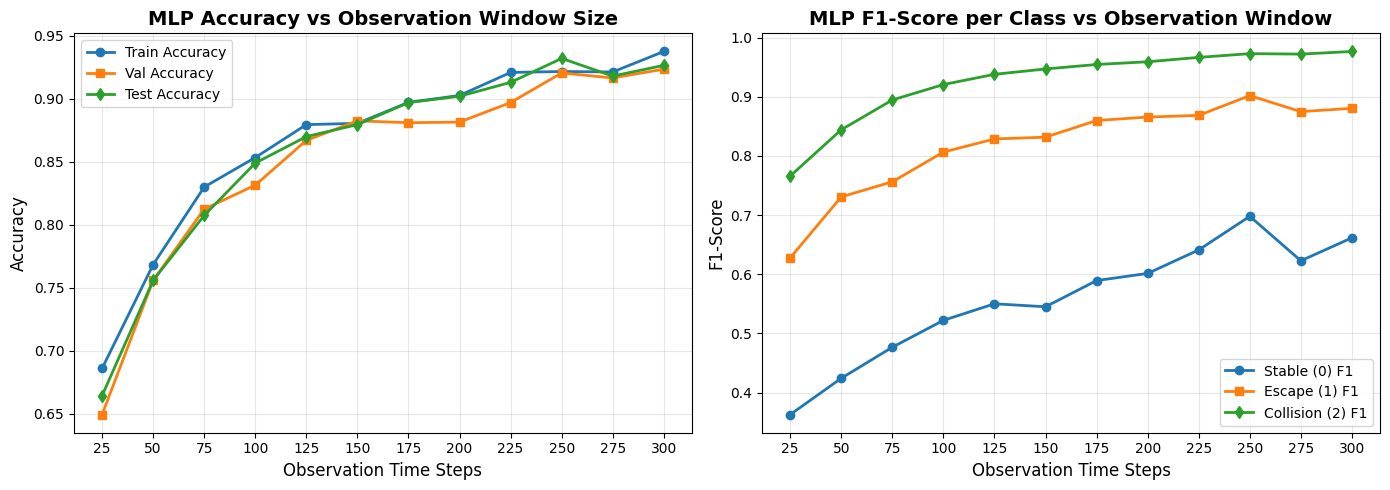


MLP SUMMARY TABLE: ACCURACY BY OBSERVATION TIME
Obs Steps    Train Acc    Val Acc      Test Acc     Stable F1    Escape F1    Collision F1
--------------------------------------------------------------------------------
25           0.6861       0.6495       0.6645       0.3628       0.6279       0.7661      
50           0.7685       0.7560       0.7560       0.4242       0.7309       0.8443      
75           0.8300       0.8125       0.8075       0.4767       0.7563       0.8946      
100          0.8534       0.8315       0.8490       0.5221       0.8066       0.9207      
125          0.8795       0.8670       0.8700       0.5501       0.8287       0.9380      
150          0.8805       0.8825       0.8795       0.5450       0.8317       0.9470      
175          0.8971       0.8810       0.8970       0.5894       0.8599       0.9546      
200          0.9026       0.8815       0.9020       0.6014       0.8657       0.9592      
225          0.9209       0.8970       0.9130      

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time
import gc  # <--- Garbage Collector for Memory Management
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# FEATURE CONTROL & MEMORY OPTIMIZATION
# ==========================================
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

# Using the top 10 features 
SELECTED_FEATURES = [
    "Dist_2_3", 
    "Speed_3", 
    "Speed_2", 
    "Vx1", 
    "Vy1", 
    "X2", 
    "Vx2", 
    "Y2", 
    "Vy2", 
    "Vy3"
]

selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# --- MEMORY FIX 1: Convert to float32 to cut RAM usage by 50% ---
X_enhanced_32 = X_enhanced.astype(np.float32)

# --- MEMORY FIX 2: Pre-slice the features so we don't do it inside the loop ---
X_selected = X_enhanced_32[:, :, selected_indices]

# ==========================================
# OBSERVATION TIME SWEEP SETUP
# ==========================================
observation_times = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

results = {
    'observation_steps': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("="*60)
print("MLP OBSERVATION TIME SWEEP (MEMORY OPTIMIZED)")
print("="*60)
print(f"Testing {len(observation_times)} different observation windows...")
print(f"Features used: {SELECTED_FEATURES}")
print("="*60)

# ==========================================
# LOOP THROUGH EACH OBSERVATION TIME
# ==========================================
for i, obs_steps in enumerate(observation_times):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(observation_times)}] Testing {obs_steps} observation steps...")
    
    # Step 1: Slice ONLY the time steps (features are already sliced)
    X_obs = X_selected[:, :obs_steps, :]
    
    # Step 2: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Step 3: Scale Data
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])
    
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)
    
    # Step 4: Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))
    
    # Step 5: Build MLP Model
    tf.keras.backend.clear_session()
    
    model = Sequential([
        # Flatten the sequence: Turns (TimeSteps, Features) into one giant flat row
        Flatten(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
        
        # Standard Fully Connected Dense Layers
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        
        # Final Output Layer
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Step 6: Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # Step 7: Evaluate
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['observation_steps'].append(obs_steps)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")
    
    # --- MEMORY FIX 3: Delete heavy variables and force Garbage Collection ---
    del X_obs, X_train, X_test, X_train_flat, X_test_flat, X_train_scaled, X_test_scaled
    gc.collect()

# ==========================================
# FINAL SWEEP SUMMARY PLOTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING FINAL SUMMARY PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Observation Time
plt.subplot(1, 2, 1)
plt.plot(results['observation_steps'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('MLP Accuracy vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

# Plot 2: F1-Score per Class vs Observation Time
plt.subplot(1, 2, 2)
plt.plot(results['observation_steps'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['observation_steps'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['observation_steps'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('MLP F1-Score per Class vs Observation Window', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("MLP SUMMARY TABLE: ACCURACY BY OBSERVATION TIME")
print("="*80)
print(f"{'Obs Steps':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(observation_times)):
    print(f"{results['observation_steps'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST MLP OBSERVATION TIME: {results['observation_steps'][best_idx]} steps")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

Preparing Data ONCE for 150 observation steps...

MLP HYPERPARAMETER SWEEP: HIDDEN LAYER SIZE
Testing 6 different MLP capacities...

[1/6] Testing MLP with 16 Base Hidden Units...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8390 | Time: 4.9s | Stopped at Epoch 6

[2/6] Testing MLP with 32 Base Hidden Units...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8690 | Time: 11.4s | Stopped at Epoch 27

[3/6] Testing MLP with 64 Base Hidden Units...


...

   Test Accuracy: 0.8765 | Time: 10.3s | Stopped at Epoch 16

[5/6] Testing MLP with 256 Base Hidden Units...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8855 | Time: 11.7s | Stopped at Epoch 17

[6/6] Testing MLP with 512 Base Hidden Units...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8745 | Time: 11.5s | Stopped at Epoch 9

EXPERIMENT COMPLETE! GENERATING HYPERPARAMETER PLOTS...


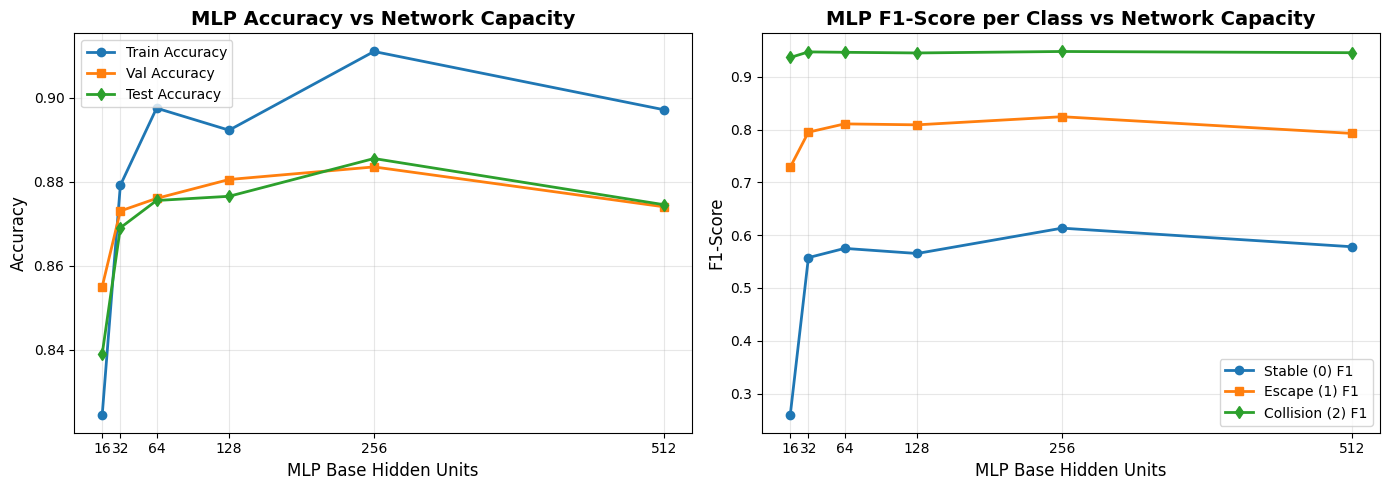


MLP HYPERPARAMETER SUMMARY: ACCURACY BY HIDDEN SIZE
Hidden Size  Train Acc    Val Acc      Test Acc     Stable F1    Escape F1    Collision F1
--------------------------------------------------------------------------------
16           0.8245       0.8550       0.8390       0.2602       0.7291       0.9366      
32           0.8791       0.8730       0.8690       0.5575       0.7951       0.9472      
64           0.8975       0.8760       0.8755       0.5750       0.8108       0.9464      
128          0.8923       0.8805       0.8765       0.5653       0.8090       0.9452      
256          0.9110       0.8835       0.8855       0.6133       0.8244       0.9479      
512          0.8971       0.8740       0.8745       0.5781       0.7928       0.9456      

 BEST MLP CAPACITY: 256 Base Hidden Units
   Best Test Accuracy: 0.8855 (88.55%)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# FEATURE CONTROL & MEMORY OPTIMIZATION
# ==========================================
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

SELECTED_FEATURES = [
    "Dist_2_3", "Speed_3", "Speed_2", "Vx1", "Vy1", "X2", "Vx2", "Y2", "Vy2", "Vy3"
]

selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# Convert to float32 to cut RAM usage
X_enhanced_32 = X_enhanced.astype(np.float32)
X_selected = X_enhanced_32[:, :, selected_indices]

# ==========================================
# FIXED DATA PREPARATION (Done only ONCE)
# ==========================================
FIXED_OBSERVATION_STEPS = 150  # Fixed observation window
print(f"Preparing Data ONCE for {FIXED_OBSERVATION_STEPS} observation steps...")

X_obs = X_selected[:, :FIXED_OBSERVATION_STEPS, :]

X_train, X_test, y_train, y_test = train_test_split(
    X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# Clear memory
del X_obs, X_train_flat, X_test_flat, X_enhanced_32, X_selected
gc.collect()

# ==========================================
# HYPERPARAMETER SWEEP SETUP
# ==========================================
hidden_sizes = [16, 32, 64, 128, 256, 512] # Added 512 since MLPs like wide layers!

results = {
    'hidden_size': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("\n" + "="*60)
print("MLP HYPERPARAMETER SWEEP: HIDDEN LAYER SIZE")
print("="*60)
print(f"Testing {len(hidden_sizes)} different MLP capacities...")
print("="*60)

# ==========================================
# LOOP THROUGH EACH HIDDEN SIZE
# ==========================================
for i, h_size in enumerate(hidden_sizes):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(hidden_sizes)}] Testing MLP with {h_size} Base Hidden Units...")
    
    tf.keras.backend.clear_session()
    
    model = Sequential([
        Flatten(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
        
        # Layer 1 gets the h_size (e.g., 128)
        Dense(h_size, activation='relu'),
        Dropout(0.3),
        
        # Layer 2 gets half of h_size (e.g., 64) to maintain the funnel architecture
        Dense(max(8, h_size // 2), activation='relu'), 
        Dropout(0.2),
        
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    results['hidden_size'].append(h_size)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s | Stopped at Epoch {len(history.epoch)}")

# ==========================================
# FINAL SWEEP SUMMARY PLOTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING HYPERPARAMETER PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Hidden Size
plt.subplot(1, 2, 1)
plt.plot(results['hidden_size'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['hidden_size'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['hidden_size'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('MLP Base Hidden Units', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('MLP Accuracy vs Network Capacity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(hidden_sizes)

# Plot 2: F1-Score per Class vs Hidden Size
plt.subplot(1, 2, 2)
plt.plot(results['hidden_size'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['hidden_size'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['hidden_size'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('MLP Base Hidden Units', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('MLP F1-Score per Class vs Network Capacity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(hidden_sizes)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("MLP HYPERPARAMETER SUMMARY: ACCURACY BY HIDDEN SIZE")
print("="*80)
print(f"{'Hidden Size':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(hidden_sizes)):
    print(f"{results['hidden_size'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST MLP CAPACITY: {results['hidden_size'][best_idx]} Base Hidden Units")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

LSTM OBSERVATION TIME SWEEP (MEMORY OPTIMIZED)
Testing 12 different observation windows...
Features used: ['Dist_2_3', 'Speed_3', 'Speed_2', 'Vx1', 'Vy1', 'X2', 'Vx2', 'Y2', 'Vy2', 'Vy3']

[1/12] Testing 25 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.6150 | Time: 9.3s

[2/12] Testing 50 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.7505 | Time: 19.6s

[3/12] Testing 75 observation steps...


...

   Test Accuracy: 0.9235 | Time: 166.7s

[11/12] Testing 275 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9235 | Time: 110.3s

[12/12] Testing 300 observation steps...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.9275 | Time: 119.6s

EXPERIMENT COMPLETE! GENERATING FINAL SUMMARY PLOTS...


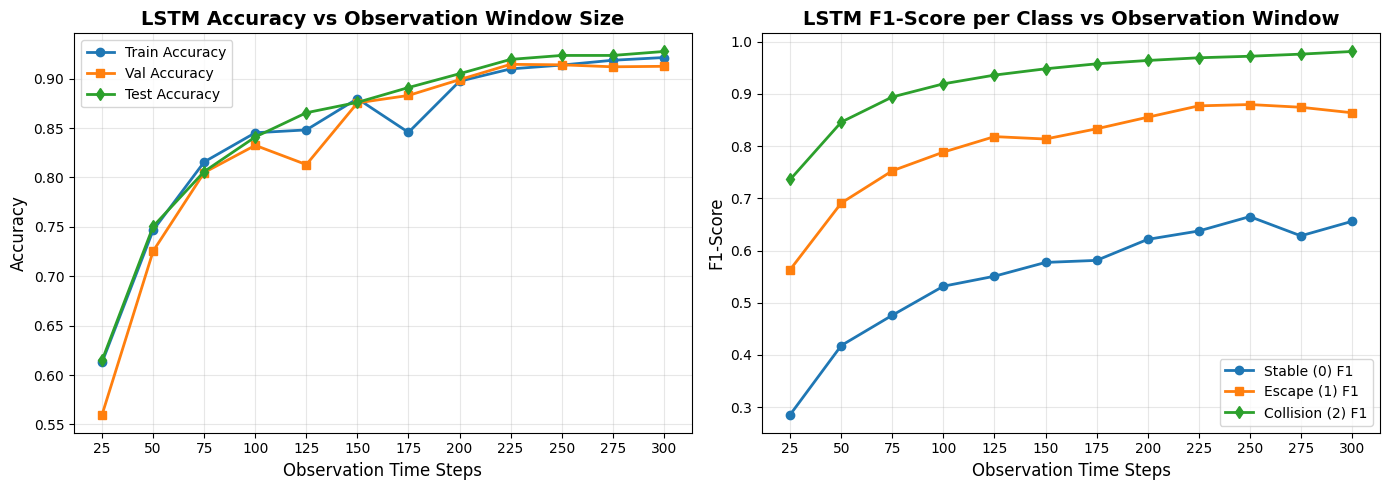


LSTM SUMMARY TABLE: ACCURACY BY OBSERVATION TIME
Obs Steps    Train Acc    Val Acc      Test Acc     Stable F1    Escape F1    Collision F1
--------------------------------------------------------------------------------
25           0.6130       0.5600       0.6150       0.2857       0.5636       0.7361      
50           0.7466       0.7255       0.7505       0.4180       0.6910       0.8460      
75           0.8158       0.8050       0.8060       0.4760       0.7527       0.8942      
100          0.8453       0.8325       0.8410       0.5316       0.7885       0.9193      
125          0.8481       0.8130       0.8655       0.5507       0.8182       0.9360      
150          0.8798       0.8755       0.8760       0.5772       0.8136       0.9481      
175          0.8456       0.8830       0.8910       0.5811       0.8331       0.9576      
200          0.8974       0.8990       0.9050       0.6213       0.8553       0.9640      
225          0.9099       0.9145       0.9195     

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time
import gc  # <--- Garbage Collector for Memory Management
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# FEATURE CONTROL & MEMORY OPTIMIZATION
# ==========================================
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

# Using the top 10 features 
SELECTED_FEATURES = [
    "Dist_2_3", 
    "Speed_3", 
    "Speed_2", 
    "Vx1", 
    "Vy1", 
    "X2", 
    "Vx2", 
    "Y2", 
    "Vy2", 
    "Vy3"
]

selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# --- MEMORY FIX 1: Convert to float32 to cut RAM usage by 50% ---
X_enhanced_32 = X_enhanced.astype(np.float32)

# --- MEMORY FIX 2: Pre-slice the features so we don't do it inside the loop ---
X_selected = X_enhanced_32[:, :, selected_indices]

# ==========================================
# OBSERVATION TIME SWEEP SETUP
# ==========================================
observation_times = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

results = {
    'observation_steps': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("="*60)
print("LSTM OBSERVATION TIME SWEEP (MEMORY OPTIMIZED)")
print("="*60)
print(f"Testing {len(observation_times)} different observation windows...")
print(f"Features used: {SELECTED_FEATURES}")
print("="*60)

# ==========================================
# LOOP THROUGH EACH OBSERVATION TIME
# ==========================================
for i, obs_steps in enumerate(observation_times):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(observation_times)}] Testing {obs_steps} observation steps...")
    
    # Step 1: Slice ONLY the time steps (features are already sliced)
    X_obs = X_selected[:, :obs_steps, :]
    
    # Step 2: Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # Step 3: Scale Data
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat = X_test.reshape(-1, X_test.shape[-1])
    
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)
    
    # Step 4: Class Weights
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))
    
    # Step 5: Build EXACT Unidirectional LSTM Model requested
    tf.keras.backend.clear_session()
    
    model = Sequential([
        # LSTM Layer reads sequence step-by-step
        LSTM(64, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Step 6: Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # Step 7: Evaluate
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['observation_steps'].append(obs_steps)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")
    
    # --- MEMORY FIX 3: Delete heavy variables and force Garbage Collection ---
    del X_obs, X_train, X_test, X_train_flat, X_test_flat, X_train_scaled, X_test_scaled
    gc.collect()

# ==========================================
# FINAL SWEEP SUMMARY PLOTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING FINAL SUMMARY PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Observation Time
plt.subplot(1, 2, 1)
plt.plot(results['observation_steps'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['observation_steps'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('LSTM Accuracy vs Observation Window Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

# Plot 2: F1-Score per Class vs Observation Time
plt.subplot(1, 2, 2)
plt.plot(results['observation_steps'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['observation_steps'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['observation_steps'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('Observation Time Steps', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('LSTM F1-Score per Class vs Observation Window', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(observation_times)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("LSTM SUMMARY TABLE: ACCURACY BY OBSERVATION TIME")
print("="*80)
print(f"{'Obs Steps':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(observation_times)):
    print(f"{results['observation_steps'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST LSTM OBSERVATION TIME: {results['observation_steps'][best_idx]} steps")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)

Preparing Data ONCE for 150 observation steps...

LSTM HYPERPARAMETER SWEEP: HIDDEN LAYER SIZE
Testing 5 different LSTM capacities...

[1/5] Testing LSTM with 16 Hidden Units...



C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8710 | Time: 27.1s | Stopped at Epoch 12

[2/5] Testing LSTM with 32 Hidden Units...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8795 | Time: 28.6s | Stopped at Epoch 11

[3/5] Testing LSTM with 64 Hidden Units...


...

   Test Accuracy: 0.8945 | Time: 79.6s | Stopped at Epoch 21

[4/5] Testing LSTM with 128 Hidden Units...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8770 | Time: 142.2s | Stopped at Epoch 14

[5/5] Testing LSTM with 256 Hidden Units...


C:\Anaconda_DML\envs\dml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   Test Accuracy: 0.8825 | Time: 411.8s | Stopped at Epoch 15

EXPERIMENT COMPLETE! GENERATING HYPERPARAMETER PLOTS...


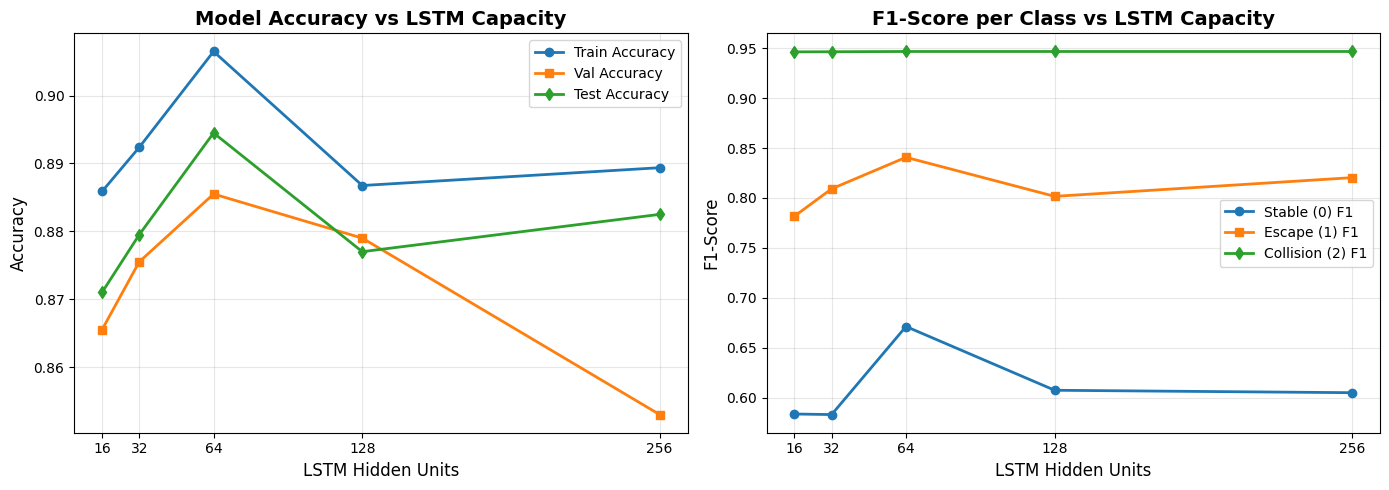


HYPERPARAMETER SUMMARY TABLE: ACCURACY BY HIDDEN SIZE
Hidden Size  Train Acc    Val Acc      Test Acc     Stable F1    Escape F1    Collision F1
--------------------------------------------------------------------------------
16           0.8859       0.8655       0.8710       0.5835       0.7817       0.9463      
32           0.8924       0.8755       0.8795       0.5829       0.8091       0.9464      
64           0.9065       0.8855       0.8945       0.6712       0.8407       0.9467      
128          0.8867       0.8790       0.8770       0.6073       0.8016       0.9467      
256          0.8894       0.8530       0.8825       0.6049       0.8203       0.9467      

 BEST LSTM CAPACITY: 64 Hidden Units
   Best Test Accuracy: 0.8945 (89.45%)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# FEATURE CONTROL & MEMORY OPTIMIZATION
# ==========================================
ALL_FEATURE_NAMES = [
    "X1", "Y1", "Vx1", "Vy1", 
    "X2", "Y2", "Vx2", "Vy2", 
    "X3", "Y3", "Vx3", "Vy3",
    "Dist_1_2", "Dist_2_3", "Dist_1_3", 
    "Speed_1", "Speed_2", "Speed_3"
]

SELECTED_FEATURES = [
    "Dist_2_3", "Speed_3", "Speed_2", "Vx1", "Vy1", "X2", "Vx2", "Y2", "Vy2", "Vy3"
]

selected_indices = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# Convert to float32 to cut RAM usage by 50%
X_enhanced_32 = X_enhanced.astype(np.float32)
X_selected = X_enhanced_32[:, :, selected_indices]

# ==========================================
# FIXED DATA PREPARATION (Done only ONCE for speed!)
# ==========================================
FIXED_OBSERVATION_STEPS = 150  # Fixed observation window for the sweep
print(f"Preparing Data ONCE for {FIXED_OBSERVATION_STEPS} observation steps...")

X_obs = X_selected[:, :FIXED_OBSERVATION_STEPS, :]

X_train, X_test, y_train, y_test = train_test_split(
    X_obs, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# Clear heavy raw variables from RAM
del X_obs, X_train_flat, X_test_flat, X_enhanced_32, X_selected
gc.collect()

# ==========================================
# HYPERPARAMETER SWEEP SETUP (Hidden Sizes)
# ==========================================
# Testing models from very small (16) to very large (256)
hidden_sizes = [16, 32, 64, 128, 256]

results = {
    'hidden_size': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'stable_f1': [],
    'escape_f1': [],
    'collision_f1': []
}

print("\n" + "="*60)
print("LSTM HYPERPARAMETER SWEEP: HIDDEN LAYER SIZE")
print("="*60)
print(f"Testing {len(hidden_sizes)} different LSTM capacities...")
print("="*60)

# ==========================================
# LOOP THROUGH EACH HIDDEN SIZE
# ==========================================
for i, h_size in enumerate(hidden_sizes):
    start_time = time.time()
    
    print(f"\n[{i+1}/{len(hidden_sizes)}] Testing LSTM with {h_size} Hidden Units...")
    
    # Build EXACT Unidirectional LSTM, but dynamic hidden size
    tf.keras.backend.clear_session()
    
    model = Sequential([
        # The first parameter is now our sweep variable (h_size)
        LSTM(h_size, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0  # Silent training
    )
    
    # Evaluate
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get metrics
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    f1_scores = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results['hidden_size'].append(h_size)
    results['train_accuracy'].append(train_acc)
    results['val_accuracy'].append(val_acc)
    results['test_accuracy'].append(test_acc)
    results['stable_f1'].append(f1_scores[0])
    results['escape_f1'].append(f1_scores[1])
    results['collision_f1'].append(f1_scores[2])
    
    elapsed = time.time() - start_time
    print(f"   Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s | Stopped at Epoch {len(history.epoch)}")

# ==========================================
# FINAL SWEEP SUMMARY PLOTS
# ==========================================
print("\n" + "="*60)
print("EXPERIMENT COMPLETE! GENERATING HYPERPARAMETER PLOTS...")
print("="*60)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy vs Hidden Size
plt.subplot(1, 2, 1)
plt.plot(results['hidden_size'], results['train_accuracy'], 'o-', label='Train Accuracy', linewidth=2)
plt.plot(results['hidden_size'], results['val_accuracy'], 's-', label='Val Accuracy', linewidth=2)
plt.plot(results['observation_steps'] if 'observation_steps' in results else results['hidden_size'], results['test_accuracy'], 'd-', label='Test Accuracy', linewidth=2)
plt.xlabel('LSTM Hidden Units', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy vs LSTM Capacity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# Set x-ticks to exactly match the tested sizes
plt.xticks(hidden_sizes)

# Plot 2: F1-Score per Class vs Hidden Size
plt.subplot(1, 2, 2)
plt.plot(results['hidden_size'], results['stable_f1'], 'o-', label='Stable (0) F1', linewidth=2)
plt.plot(results['hidden_size'], results['escape_f1'], 's-', label='Escape (1) F1', linewidth=2)
plt.plot(results['hidden_size'], results['collision_f1'], 'd-', label='Collision (2) F1', linewidth=2)
plt.xlabel('LSTM Hidden Units', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Score per Class vs LSTM Capacity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(hidden_sizes)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("HYPERPARAMETER SUMMARY TABLE: ACCURACY BY HIDDEN SIZE")
print("="*80)
print(f"{'Hidden Size':<12} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Stable F1':<12} {'Escape F1':<12} {'Collision F1':<12}")
print("-"*80)
for i in range(len(hidden_sizes)):
    print(f"{results['hidden_size'][i]:<12} {results['train_accuracy'][i]:<12.4f} {results['val_accuracy'][i]:<12.4f} {results['test_accuracy'][i]:<12.4f} {results['stable_f1'][i]:<12.4f} {results['escape_f1'][i]:<12.4f} {results['collision_f1'][i]:<12.4f}")
print("="*80)

best_idx = np.argmax(results['test_accuracy'])
print(f"\n BEST LSTM CAPACITY: {results['hidden_size'][best_idx]} Hidden Units")
print(f"   Best Test Accuracy: {results['test_accuracy'][best_idx]:.4f} ({results['test_accuracy'][best_idx]*100:.2f}%)")
print("="*80)